<div style="padding:28px;border-radius:18px;background:linear-gradient(135deg,#0f172a,#1e3a5f);color:white">
<div style="font-size:13px;letter-spacing:2px;font-weight:700">TUTORIAL OF AGENTIC SYSTEMS · ALGORITHMIC TRADING</div>
<h1 style="margin:8px 0 6px 0;font-size:34px">Notebook 05 — Build Dynamic Agentic Ecosystems</h1>
<div style="font-size:18px;opacity:.9">Discovery, negotiation, shared knowledge, and temporary alliances</div></div>

### Introduction

The previous notebook allowed one organization to assemble and reorganize its specialist team. Notebook 05 gives several constellations separate identities and allows them to interact. This is the conceptual counterpart of multiple investment banking teams discovering complementary capabilities, exchanging evidence, and forming temporary collaborations around an opportunity. The new object of study is the relationship between organizations.

We begin with Growth, Recovery, and Preservation constellations. Each has its own membership, an inbox, a small service budget, and a record of received knowledge. Their capabilities overlap imperfectly. As conditions change, a team can discover a gap that another constellation is able to fill. That gap initiates a request, an offer, a counteroffer, and either acceptance or rejection.

Accepted requests create explicit service contracts. A provider delivers a timestamped ranking, and the requesting team incorporates the complementary strategy into a temporary joint decision. Provider capacity is limited, so every request cannot be accepted. Contracts expire, and obsolete alliances dissolve. These events are part of the executable system, not merely labels added to an otherwise static portfolio calculation.

We compare this connected ecosystem against the same constellations operating without external collaboration. Both use the same market, decision dates, portfolio rule, review process, and execution costs. Differences in allocations and performance can therefore be related to the interaction mechanism, although one synthetic experiment cannot establish a universal advantage for collaboration.

The final evaluation also reconnects outcomes to the hidden economic regimes, after decisions have been completed. This closes the pedagogical journey: we started with a shared world and individual actions, and arrive at organizations that can exchange capabilities and create temporary configurations in response to changing conditions.

This notebook contains ten executable code units, each preceded by an explanation and a question for reflection. Run them in order and inspect their outputs before continuing. The supporting Python modules preserve earlier building blocks, while the new mechanisms are shown directly in the cells. All investment activity remains inside the synthetic simulation.

**Portfolio mandate:** five unique stocks, 20% per stock at each rebalance. **Model:** `gpt-5-nano` in optional live demonstrations. **Default:** deterministic teaching policy. **Separate download — no ZIP required.** Open this file in Colab. Run NB00 first, then NB01–NB05 in order. Code unit 1 creates the shared project folder and installs the embedded course modules. In Colab, authorize the Google Drive mount so all notebooks share their dataset and results. Use `LIVE_LLM=False` initially. For optional live calls, run `%pip install openai` in a temporary cell, add `OPENAI_API_KEY` to Colab Secrets, and enable notebook access. Historical example outputs are retained; rerun the cells to produce your own results.

<div style="padding:20px;border-left:6px solid #2563eb;background:#eff6ff;border-radius:10px;color:#0f172a"><b>What we need to understand and learn</b></div>

An ecosystem requires more than several teams running side by side. Each constellation must have an identity, some locally held state, and an interface through which other constellations can request or provide a service. The three teams in this notebook therefore maintain inboxes, knowledge records, and credits. The directory exposes their available capabilities, but it does not assume every team already possesses every capability.

Discovery begins when observed conditions imply a capability gap. A requester asks the directory for complementary services. Providers whose capabilities overlap the gap can submit an offer, subject to their remaining service capacity. The requester's budget can be lower than the initial ask, which produces a counteroffer. Acceptance requires a minimum reservation price and an available capacity slot. A rejected request remains in the message log with a reason.

The negotiation is intentionally simple and transparent. Credits are reset each decision cycle and are consumed as an access quota; they are not a conserved currency, provider revenue, or a model of equilibrium service pricing. A provider can serve one external requester per cycle. These limits create scarcity and make request ordering matter. That consequence is useful: students can ask whether a different allocation rule would be fairer or more effective without confusing this teaching protocol with an optimal marketplace.

An accepted contract creates a temporary alliance whose membership combines the requester and provider capabilities. The provider delivers a timestamped ranking. The requesting decision incorporates those complementary rankings, so information exchange has an observable consequence for portfolio selection. The final ecosystem portfolio aggregates the three team decisions and again selects five unique stocks. The same independent review and execution gates remain in force.

Alliances have expiry dates. A later cycle dissolves expired configurations and can form new ones if conditions still justify collaboration. The result is a changing network of relationships, not an unlimited expansion of permanent teams. We compare connected and isolated systems to identify differences caused by access to peer capabilities. The notebook demonstrates bounded emergent coordination: configurations arise from local gaps, offers, budgets, and capacity constraints inside explicitly engineered rules.

The protocol creates behavior that is not specified as one fixed global team schedule. Which alliance exists depends on observed needs, peer capabilities, available capacity, and the order of requests. That is the limited sense in which coordination emerges here. It does not imply consciousness, unbounded creativity, or an unexplained ability to optimize the entire system.

A useful extension is to reverse requester order while keeping every other rule unchanged. Capacity constraints can then allocate the same provider to a different team. Comparing contract logs reveals an organizational effect before performance is examined. Another extension is to shorten contract duration and observe whether unnecessary coordination increases. Both exercises preserve the basic lesson that relationships have a lifecycle and a resource cost.

Keep local knowledge distinct from the global evaluator. A received signal belongs to a dated contract and a specific recipient. Teacher regimes belong only to retrospective analysis. Confusing those channels would turn a study of inter-team communication into an experiment with privileged future information.

As you work, distinguish the object being observed, the function transforming it, the component authorized to act, and the evidence retained afterward. These distinctions recur throughout the ladder and make each additional level of organization easier to reason about.

### Code Unit 1 of 10 — Reconnect the cumulative system before adding peers

The setup reconnects NB05 to the same market, capability catalog, investment engine, and the repaired support modules carried forward from NB04. This makes the ecosystem stage an extension of the preceding architecture. The new mechanism will concern peer identities, service requests, and temporary relationships. Strategy formulas and the five-stock mandate remain common. The notebook assumes the earlier course notebooks have established the shared project folder and dataset, and it installs the current cumulative course modules into that same folder before loading the market and rebalance schedule. Reusing these artifacts keeps the interpretation cumulative rather than restarting the course.

**Expected observation.** The setup should restore the same underlying capabilities and decision dates. Ecosystem interactions are the new experimental variable. Changing the dataset or accounting conventions here would make the comparison with earlier levels much harder to interpret.

After execution, compare the output with the stated contract and trace at least one value back to its input. If a check fails, resolve the cause before continuing, because later units rely on this result.

**Reflect:** Which new object distinguishes an ecosystem from one adaptive team?

**Implementation note.** Earlier versions of this cell rejected any support module whose contents differed byte-for-byte from the embedded copy. That was incompatible with a cumulative tutorial after NB04 had legitimately been repaired. The setup now carries the repaired NB04 modules forward explicitly, so NB05 begins from the current course architecture rather than mistaking an upgrade for corruption.


In [ ]:
# @title
# Standalone download: supporting Python modules are embedded below. Run NB00 first.
from pathlib import Path
import sys, os, json, hashlib
from dataclasses import dataclass, field
from functools import lru_cache
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except ImportError:
    def display(value): print(value)

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    ROOT = Path('/content/drive/MyDrive/Colab Notebooks/TOPIC_767 ALGORITHMIC_TRADING_AGENTIC_SYSTEMS')
else:
    ROOT = Path.cwd() / 'ALGORITHMIC_TRADING_AGENTIC_SYSTEMS'
ROOT.mkdir(parents=True, exist_ok=True)
# These readable source strings contain the same course modules used by the ZIP.
EMBEDDED_MODULES = {'__init__.py': '"""Transparent cumulative support code for NB00–NB05. See each module\'s matching notebook."""\n', 'adaptation.py': '"""NB04: capability discovery, constrained formation, and explicit reconfiguration."""\nfrom .loops import *\nfrom itertools import combinations\n\n@dataclass(frozen=True)\nclass Capability:\n    agent: str\n    tags: frozenset\n    cost: int\n\nCATALOG=[Capability(\'momentum\',frozenset([\'trend\',\'growth\']),2),\n         Capability(\'value\',frozenset([\'valuation\',\'recovery\']),2),\n         Capability(\'quality\',frozenset([\'resilience\',\'fundamentals\']),2),\n         Capability(\'defensive\',frozenset([\'resilience\',\'low_volatility\']),1),\n         Capability(\'reversion\',frozenset([\'reversal\',\'recovery\']),1)]\nMANDATORY=[\'environment\',\'coordinator\',\'review\',\'execution\']\n\ndef required_capabilities(environment):\n    if environment[\'estimate\']==\'stress\': return {\'resilience\',\'low_volatility\'}\n    if environment[\'estimate\']==\'inflation_pressure\': return {\'valuation\',\'resilience\'}\n    if environment[\'trend\']<0: return {\'recovery\',\'resilience\'}\n    return {\'trend\',\'fundamentals\'}\n\ndef discover_and_form(required,catalog=CATALOG,budget=5,scores=None):\n    scores=scores or {};candidates=[]\n    for n in range(1,len(catalog)+1):\n        for team in combinations(catalog,n):\n            tags=set().union(*(c.tags for c in team));cost=sum(c.cost for c in team)\n            if not required<=tags or cost>budget: continue\n            utility=sum(scores.get(c.agent,0) for c in team)/len(team)-.01*cost\n            candidates.append((utility,tuple(c.agent for c in team),cost))\n    if not candidates: raise ValueError(\'Capability request cannot be covered within budget.\')\n    candidates.sort(key=lambda x:(-x[0],x[2],x[1]))\n    return [{\'agents\':list(t),\'cost\':c,\'utility\':u} for u,t,c in candidates]\n\ndef validate_plan(plan,required,catalog=CATALOG,budget=5):\n    known={c.agent:c for c in catalog};names=plan[\'agents\']\n    if len(names)!=len(set(names)) or any(n not in known for n in names): raise ValueError(\'Invalid plan members.\')\n    tags=set().union(*(known[n].tags for n in names))\n    if not required<=tags or sum(known[n].cost for n in names)>budget: raise ValueError(\'Invalid plan coverage or cost.\')\n    if plan.get(\'mandatory\',MANDATORY)!=MANDATORY: raise ValueError(\'Control roles cannot be removed.\')\n    return True\n\ndef form_plan(view,asof,scores=None,previous=None,live=False,cache_dir=\'CACHE\'):\n    env=view.environment(asof);required=required_capabilities(env)\n    candidates=discover_and_form(required,scores=scores)\n    options={f\'plan_{i}\':p for i,p in enumerate(candidates)}\n    prompt_payload={\n        \'mission\':\'Choose one already-feasible specialist team for the observed conditions.\',\n        \'decision_rule\':\'Use the observed environment, required capabilities, trailing specialist scores, team cost, and unnecessary complexity. Do not assume plan_0 is best merely because it is listed first.\',\n        \'environment\':env,\n        \'required\':sorted(required),\n        \'trailing_scores\':scores or {},\n        \'previous_team\':list(previous or []),\n        \'candidates\':options\n    }\n    result=choose_with_model(json.dumps(prompt_payload,default=str),options,\n            lambda key:options[key],cache_dir,live,\'plan_0\')\n    plan=dict(result[\'result\']);plan[\'mandatory\']=MANDATORY.copy()\n    validate_plan(plan,required)\n    old=set(previous or []);new=set(plan[\'agents\'])\n    plan.update({\n        \'required\':sorted(required),\n        \'environment\':env,\n        \'added\':sorted(new-old),\n        \'removed\':sorted(old-new),\n        \'edges\':[[\'environment\',a] for a in plan[\'agents\']]\n                +[[a,\'coordinator\'] for a in plan[\'agents\']]\n                +[[\'coordinator\',\'review\'],[\'review\',\'execution\']],\n        \'mode\':result[\'mode\'],\n        \'selector_choice\':result.get(\'choice\'),\n        \'selector_explanation\':result.get(\'explanation\',\'\')\n    })\n    return plan\n\ndef adaptive_policy(view,shadow,live_mode=False,cache_dir=\'CACHE\'):\n    previous=[]\n    def policy(asof,context):\n        nonlocal previous\n        influence,scores=feedback_influence(shadow,asof)\n        plan=form_plan(view,asof,scores,previous,live=live_mode,cache_dir=cache_dir)\n        packet=run_constellation(view,asof,plan[\'agents\'],influence)\n        previous=plan[\'agents\']\n        label=\'reconfigured_team_llm\' if live_mode else \'reconfigured_team_deterministic\'\n        return packet[\'decision\'],{\'active\':previous.copy(),\'plan\':plan,\'policy\':label}\n    return policy\n\ndef topology_table(events):\n    return pd.DataFrame([{\'asof\':e[\'asof\'],\'active\':\', \'.join(e[\'active\']),\n        \'added\':\', \'.join(e.get(\'plan\',{}).get(\'added\',[])),\n        \'removed\':\', \'.join(e.get(\'plan\',{}).get(\'removed\',[])),\n        \'requirements\':\', \'.join(e.get(\'plan\',{}).get(\'required\',[]))} for e in events])\n', 'constellations.py': '"""NB02: fixed collaboration, independent review, next-close simulated execution."""\nfrom .primitives import *\n\n@dataclass\nclass ReviewAgent:\n    min_adv: float = 1_000_000\n    sector_cap: float = .6\n    def review(self, proposal, snapshot):\n        errors=[];w=proposal.get(\'weights\',{})\n        if len(w)!=5: errors.append(\'exactly_five_unique_stocks_required\')\n        if any(t not in snapshot.index for t in w): errors.append(\'unknown_stock\')\n        try:\n            if not all(np.isfinite(v) and abs(v-.2)<1e-10 for v in w.values()): errors.append(\'equal_weights_required\')\n            if abs(sum(w.values())-1)>1e-10: errors.append(\'fully_invested_required\')\n        except (TypeError,ValueError): errors.append(\'non_numeric_weight\')\n        if not errors:\n            sectors={}\n            for t,v in w.items():\n                s=snapshot.loc[t];sectors[s.sector]=sectors.get(s.sector,0)+v\n                if s.adv<self.min_adv: errors.append(\'insufficient_liquidity\')\n                if s.published_at>pd.Timestamp(proposal[\'asof\']): errors.append(\'future_fundamental\')\n                if s[\'asof\']!=pd.Timestamp(proposal[\'asof\']): errors.append(\'stale_snapshot\')\n            if max(sectors.values())>self.sector_cap+1e-10: errors.append(\'sector_concentration\')\n        digest=hashlib.sha256(json.dumps(proposal,sort_keys=True,default=str).encode()).hexdigest()\n        return {\'approved\':not errors,\'errors\':sorted(set(errors)),\'proposal_hash\':digest,\'role\':\'independent_review\'}\n\ndef integrate(proposals, snapshot, influence=None, sector_cap=.6):\n    if not proposals: raise ValueError(\'No specialist proposals.\')\n    influence=influence or {p[\'owner\']:1/len(proposals) for p in proposals}\n    total=sum(influence.get(p[\'owner\'],0) for p in proposals)\n    if total<=0: raise ValueError(\'No positive influence.\')\n    score=pd.Series(0.,index=snapshot.index)\n    for p in proposals:\n        if pd.Timestamp(p[\'asof\'])!=snapshot[\'asof\'].iloc[0]: raise ValueError(\'Mixed observation dates.\')\n        score+=pd.Series(p[\'ranking\']).reindex(score.index).fillna(0)*influence.get(p[\'owner\'],0)/total\n    order=pd.DataFrame({\'score\':score,\'ticker\':score.index})\n    order=order.rename_axis(None)\n    order=order.sort_values([\'score\',\'ticker\'],ascending=[False,True])\n    chosen=[];count={}\n    for t in order.index:\n        sector=snapshot.loc[t,\'sector\']\n        if snapshot.loc[t,\'adv\']<1_000_000 or (count.get(sector,0)+1)*.2>sector_cap+1e-10: continue\n        chosen.append(t);count[sector]=count.get(sector,0)+1\n        if len(chosen)==5: break\n    if len(chosen)!=5: raise ValueError(\'No feasible five-stock portfolio.\')\n    return {\'owner\':\'coordinator\',\'style\':\'consensus\',\'asof\':str(snapshot[\'asof\'].iloc[0].date()),\n            \'weights\':{t:.2 for t in chosen},\'ranking\':score.to_dict(),\n            \'contributors\':[p[\'owner\'] for p in proposals]}\n\n@dataclass\nclass ExecutionAgent:\n    fee_bps: float = 5.\n    slippage_bps: float = 5.\n    def execute(self, proposal, review, view, shares, cash):\n        digest=hashlib.sha256(json.dumps(proposal,sort_keys=True,default=str).encode()).hexdigest()\n        if not review[\'approved\'] or digest!=review[\'proposal_hash\']: raise PermissionError(\'No valid approval for this exact proposal.\')\n        asof=pd.Timestamp(proposal[\'asof\']);i=view.dates.searchsorted(asof,side=\'right\')\n        if i>=len(view.dates): raise ValueError(\'No subsequent execution date.\')\n        date=view.dates[i];px=view.close.loc[date]\n        shares=shares.reindex(px.index,fill_value=0.);old=shares*px\n        nav=float(old.sum()+cash);w=pd.Series(proposal[\'weights\']).reindex(px.index,fill_value=0.)\n        rate=(self.fee_bps+self.slippage_bps)/10_000\n        if not 0<=rate<.1: raise ValueError(\'Invalid cost rate.\')\n        # Solve post-cost NAV so target holdings plus costs exactly consume available capital.\n        net=nav\n        for _ in range(100):\n            newnet=nav-rate*float((w*net-old).abs().sum())\n            if abs(newnet-net)<1e-9: net=newnet;break\n            net=newnet\n        trade=w*net-old;cost=float(trade.abs().sum()*rate)\n        adv=(view.close.loc[:asof].tail(20)*view.volume.loc[:asof].tail(20)).mean()\n        if (trade.abs()>adv*.02).any(): raise PermissionError(\'Order exceeds 2% of observed ADV.\')\n        newshares=w*net/px\n        ledger=pd.DataFrame({\'ticker\':px.index,\'shares_before\':shares.values,\'shares_after\':newshares.values,\n            \'reference_price\':px.values,\'traded_notional\':trade.values,\'cost\':trade.abs().values*rate})\n        ledger=ledger[ledger.traded_notional.abs()>1e-8]\n        return {\'date\':date,\'shares\':newshares,\'cash\':nav-float((newshares*px).sum())-cost,\n                \'cost\':cost,\'turnover\':float(trade.abs().sum()/nav),\'nav_before\':nav,\'nav_after\':net,\'ledger\':ledger}\n\ndef run_constellation(view,asof,styles=None,influence=None,live=False,cache_dir=\'CACHE\'):\n    styles=styles or STYLES\n    agents=[StrategyAgent(s,(s,)) for s in styles]\n    packets=[a.act(view,asof,live,cache_dir) for a in agents]\n    proposals=[p[\'result\'] for p in packets];snapshot=view.snapshot(asof)\n    decision=integrate(proposals,snapshot,influence)\n    review=ReviewAgent().review(decision,snapshot)\n    return {\'proposals\':proposals,\'decision\':decision,\'review\':review,\n            \'messages\':[{\'from\':p[\'owner\'],\'to\':\'coordinator\',\'asof\':p[\'asof\'],\'top5\':list(p[\'weights\'])} for p in proposals],\n            \'modes\':[p[\'mode\'] for p in packets]}\n', 'ecosystem.py': '"""NB05: stateful constellations, service discovery, negotiation, leases and alliances."""\nfrom .adaptation import *\n\n@dataclass\nclass Constellation:\n    name: str\n    members: list\n    credits: int = 3\n    inbox: list = field(default_factory=list)\n    knowledge: dict = field(default_factory=dict)\n    def tags(self):\n        return set().union(*(c.tags for c in CATALOG if c.agent in self.members))\n\nclass Ecosystem:\n    def __init__(self,collaborate=True):\n        self.teams={c.name:c for c in [Constellation(\'Growth\',[\'momentum\',\'quality\']),\n                    Constellation(\'Recovery\',[\'value\',\'reversion\']),Constellation(\'Preservation\',[\'defensive\'])]}\n        self.collaborate=collaborate;self.contracts=[];self.messages=[];self.alliances={};self.counter=0\n    def send(self,kind,sender,recipient,date,**payload):\n        message={\'kind\':kind,\'from\':sender,\'to\':recipient,\'asof\':str(pd.Timestamp(date).date()),**payload}\n        self.messages.append(message)\n        if recipient in self.teams:self.teams[recipient].inbox.append(message)\n        return message\n    def expire(self,asof):\n        for k,a in list(self.alliances.items()):\n            if pd.Timestamp(a[\'expires\'])<=pd.Timestamp(asof):\n                self.send(\'dissolve\',k,\'directory\',asof,reason=\'lease_expired\')\n                del self.alliances[k]\n        for c in self.contracts:\n            if c[\'status\']==\'active\' and pd.Timestamp(c[\'expires\'])<=pd.Timestamp(asof):c[\'status\']=\'expired\'\n    def coordinate(self,view,asof,required,live=False,cache_dir=\'CACHE\'):\n        self.expire(asof)\n        for team in self.teams.values():team.credits=3\n        capacity={name:1 for name in self.teams} # At most one external service per provider per cycle.\n        env=view.environment(asof)\n        native={name:run_constellation(view,asof,t.members)[\'decision\'] for name,t in self.teams.items()}\n        combined=[];created=[]\n        for name,team in self.teams.items():\n            members=team.members.copy();missing=required-team.tags()\n            contributions=[native[name]]\n            if self.collaborate and missing:\n                self.send(\'request\',name,\'directory\',asof,capabilities=sorted(missing),budget=team.credits)\n                offers=[]\n                for peer,provider in self.teams.items():\n                    if peer==name or not (provider.tags()&missing):continue\n                    if capacity[peer]==0:\n                        self.send(\'reject\',peer,name,asof,reason=\'provider_capacity_exhausted\');continue\n                    ask=4\n                    self.send(\'offer\',peer,name,asof,price=ask,capabilities=sorted(provider.tags()&missing))\n                    counter=team.credits\n                    self.send(\'counteroffer\',name,peer,asof,price=counter)\n                    if counter<2:\n                        self.send(\'reject\',peer,name,asof,reason=\'below_provider_reservation_price\');continue\n                    offers.append(peer)\n                if offers:\n                    choice=choose_with_model(json.dumps({\'mission\':\'Select a peer service for this capability gap.\',\n                        \'requester\':name,\'missing\':sorted(missing),\'providers\':{p:sorted(self.teams[p].tags()) for p in offers},\n                        \'environment\':env}),offers,lambda p:{\'provider\':p},cache_dir,live,offers[0])[\'choice\']\n                    provider=self.teams[choice];price=team.credits;team.credits-=price;capacity[choice]-=1\n                    self.counter+=1;alliance_id=f\'Alliance_{self.counter:04d}\'\n                    members=sorted(set(members+provider.members))\n                    expiry=pd.Timestamp(asof)+pd.Timedelta(days=25)\n                    contract={\'id\':alliance_id,\'requester\':name,\'provider\':choice,\'price\':price,\'status\':\'active\',\n                              \'asof\':str(pd.Timestamp(asof).date()),\'expires\':str(expiry.date()),\'members\':members}\n                    self.contracts.append(contract);self.alliances[alliance_id]=contract.copy();created.append(alliance_id)\n                    self.send(\'accept\',name,choice,asof,contract=alliance_id,price=price)\n                    signal={\'asof\':str(pd.Timestamp(asof).date()),\'source\':choice,\'ranking\':native[choice][\'ranking\']}\n                    team.knowledge[f\'{asof}:{choice}\']=signal\n                    contributions.append({\'owner\':choice,\'asof\':signal[\'asof\'],\'ranking\':signal[\'ranking\']})\n                    self.send(\'deliver\',choice,name,asof,contract=alliance_id,signal=signal)\n                    self.send(\'form\',alliance_id,\'directory\',asof,members=members)\n            # Exchanged provider rankings actually influence the requester\'s portfolio.\n            combined.append(integrate(contributions,view.snapshot(asof)))\n            combined[-1][\'owner\']=name\n        decision=integrate(combined,view.snapshot(asof))\n        decision[\'owner\']=\'ecosystem_coordinator\'\n        return decision,{\'active\':sorted(set(s for t in self.teams.values() for s in t.members)),\n            \'alliances_created\':created,\'active_alliances\':list(self.alliances),\n            \'required\':sorted(required),\'policy\':\'collaborating_ecosystem\' if self.collaborate else \'isolated_constellations\',\n            \'credits_remaining\':{n:t.credits for n,t in self.teams.items()}}\n\ndef ecosystem_policy(view,ecosystem):\n    def policy(asof,context):\n        return ecosystem.coordinate(view,asof,required_capabilities(view.environment(asof)))\n    return policy\n\ndef sector_weights(positions):\n    return positions.pivot_table(index=\'execution_date\',columns=\'sector\',values=\'target_weight\',aggfunc=\'sum\',fill_value=0)\n\ndef regime_evaluation(equities,teacher):\n    labels=teacher.set_index(\'date\').regime\n    rows=[]\n    for name,e in equities.items():\n        joined=e.pct_change().rename(\'return\').to_frame().join(labels).dropna()\n        for regime,g in joined.groupby(\'regime\'):\n            rows.append({\'book\':name,\'regime\':regime,\'days\':len(g),\'mean_daily_return\':g[\'return\'].mean(),\n                \'daily_volatility\':g[\'return\'].std(),\'compounded_selected_days\':(1+g[\'return\']).prod()-1})\n    return pd.DataFrame(rows)\n', 'loops.py': '"""NB03: fixed team, changing state, causal feedback and portfolio accounting."""\nfrom .constellations import *\n\ndef rebalance_dates(view,start=252,stop=None):\n    dates=view.dates[start:stop if stop is not None else len(view.dates)-1]\n    return pd.Series(dates,index=dates).groupby(dates.to_period(\'M\')).last().tolist()\n\ndef feedback_influence(shadow, asof):\n    scores={}\n    for s,e in shadow.items():\n        h=e.loc[:asof].tail(64)\n        scores[s]=float(h.iloc[-1]/h.iloc[0]-1) if len(h)>1 else 0.\n    raw=np.exp(np.clip(np.array(list(scores.values()))*5,-2,2))\n    weights=dict(zip(scores,(raw/raw.sum()).tolist()))\n    return weights,scores\n\ndef run_book(view, policy, label, dates=None, fee_bps=5, slippage_bps=5, capital=100_000.):\n    dates=dates or rebalance_dates(view)\n    if not dates: raise ValueError(\'Empty schedule.\')\n    shares=pd.Series(0.,index=view.close.columns);cash=capital\n    start=pd.Timestamp(dates[0]);equity=pd.Series(index=view.dates[view.dates>=start],dtype=float)\n    events=[];positions=[];orders=[];previous=start\n    for asof in dates:\n        # Mark old shares up to and including decision date. No reset to 20% between trades.\n        interval=view.close.loc[previous:asof]\n        equity.loc[interval.index]=interval.mul(shares,axis=1).sum(axis=1)+cash\n        context={\'asof\':asof,\'past_events\':events.copy(),\'equity\':equity.loc[:asof].dropna().copy()}\n        decision,meta=policy(asof,context)\n        snapshot=view.snapshot(asof);review=ReviewAgent().review(decision,snapshot)\n        try:\n            fill=ExecutionAgent(fee_bps,slippage_bps).execute(decision,review,view,shares,cash)\n        except PermissionError as exc:\n            events.append({\'asof\':str(asof.date()),\'status\':\'rejected\',\'reason\':str(exc),**meta})\n            previous=asof;continue\n        # Old holdings earn the decision-close to next-close move; new holdings start after the fill.\n        equity.loc[fill[\'date\']]=fill[\'nav_after\']\n        shares,cash=fill[\'shares\'],fill[\'cash\'];previous=fill[\'date\']\n        events.append({\'asof\':str(asof.date()),\'execution_date\':str(fill[\'date\'].date()),\'status\':\'filled\',\n            \'cost\':fill[\'cost\'],\'turnover\':fill[\'turnover\'],\'nav\':fill[\'nav_after\'],**meta})\n        positions.extend({\'asof\':str(asof.date()),\'execution_date\':str(fill[\'date\'].date()),\'ticker\':t,\'target_weight\':w,\n                          \'sector\':snapshot.loc[t,\'sector\'],\'book\':label} for t,w in decision[\'weights\'].items())\n        orders.append(fill[\'ledger\'].assign(date=fill[\'date\'],book=label))\n    tail=view.close.loc[previous:];equity.loc[tail.index]=tail.mul(shares,axis=1).sum(axis=1)+cash\n    return {\'equity\':equity.dropna(),\'events\':events,\'positions\':pd.DataFrame(positions),\n            \'orders\':pd.concat(orders,ignore_index=True) if orders else pd.DataFrame(),\'label\':label}\n\ndef fixed_policy(view,styles=None,influence=None):\n    styles=styles or STYLES\n    def policy(asof,context):\n        packet=run_constellation(view,asof,styles,influence)\n        return packet[\'decision\'],{\'active\':styles,\'influence\':influence or {s:1/len(styles) for s in styles},\'policy\':\'fixed\'}\n    return policy\n\ndef feedback_policy(view,shadow):\n    def policy(asof,context):\n        influence,scores=feedback_influence(shadow,asof)\n        packet=run_constellation(view,asof,STYLES,influence)\n        return packet[\'decision\'],{\'active\':STYLES,\'influence\':influence,\'observed_trailing_returns\':scores,\'policy\':\'fixed_team_feedback\'}\n    return policy\n\ndef performance(equity):\n    r=equity.pct_change().dropna();n=len(r)\n    peak=equity.cummax();dd=equity/peak-1\n    return {\'total_return\':float(equity.iloc[-1]/equity.iloc[0]-1),\n            \'annualized_return\':float((equity.iloc[-1]/equity.iloc[0])**(252/max(n,1))-1),\n            \'annualized_volatility\':float(r.std()*np.sqrt(252)),\n            \'max_drawdown\':float(dd.min()),\'observations\':n}\n\ndef compare_books(books):\n    table=pd.DataFrame({k:performance(b[\'equity\']) for k,b in books.items()}).T\n    table[\'total_cost\']=[sum(e.get(\'cost\',0) for e in b[\'events\']) for b in books.values()]\n    table[\'traded_notional_turnover\']=[sum(e.get(\'turnover\',0) for e in b[\'events\']) for b in books.values()]\n    return table\n\ndef plot_books(books,title):\n    eq=pd.DataFrame({k:b[\'equity\'] for k,b in books.items()}).dropna()\n    (eq/eq.iloc[0]).plot(figsize=(11,4),title=title)\n    plt.ylabel(\'Initial NAV = 1\');plt.tight_layout();plt.show()\n\ndef save_book(book,folder):\n    folder=Path(folder);folder.mkdir(parents=True,exist_ok=True);name=book[\'label\']\n    book[\'equity\'].rename(\'nav\').to_csv(folder/f\'{name}_equity.csv\',index_label=\'date\')\n    book[\'positions\'].to_csv(folder/f\'{name}_positions.csv\',index=False)\n    book[\'orders\'].to_csv(folder/f\'{name}_orders.csv\',index=False)\n    (folder/f\'{name}_events.json\').write_text(json.dumps(book[\'events\'],default=str,indent=2))\n\ndef load_shadow(folder):\n    return {s:pd.read_csv(Path(folder)/f\'{s}_equity.csv\',index_col=\'date\',parse_dates=True).nav for s in STYLES}\n', 'primitives.py': '"""NB01: deterministic tools, reusable skills and bounded agent decisions."""\nfrom .world import *\nfrom dataclasses import dataclass, field\nimport os\n\n@dataclass\nclass CallBudget:\n    limit: int = 12\n    used: int = 0\n    records: list = field(default_factory=list)\n    def reserve(self):\n        if self.used >= self.limit: raise RuntimeError(\'API call budget exhausted.\')\n        self.used += 1\n\nBUDGET = CallBudget()\n\ndef api_key():\n    key=os.environ.get(\'OPENAI_API_KEY\')\n    if not key:\n        try:\n            from google.colab import userdata\n            key=userdata.get(\'OPENAI_API_KEY\')\n        except Exception:\n            pass\n    if not key:\n        raise RuntimeError(\n            \'OPENAI_API_KEY is not available. Add it once to Colab Secrets \'\n            \'with the exact name OPENAI_API_KEY and enable notebook access.\'\n        )\n    return key\n\ndef _extract_response_text(payload):\n    """\n    Extract the assistant\'s final text from a raw Responses API payload.\n\n    We intentionally look for final output_text content rather than reasoning\n    items. This keeps the planning decision separate from internal reasoning.\n    """\n    if not isinstance(payload, dict):\n        return \'\'\n\n    direct=payload.get(\'output_text\')\n    if isinstance(direct, str) and direct.strip():\n        return direct.strip()\n\n    for item in payload.get(\'output\', []) or []:\n        if not isinstance(item, dict):\n            continue\n        if item.get(\'type\') != \'message\':\n            continue\n        for content in item.get(\'content\', []) or []:\n            if not isinstance(content, dict):\n                continue\n            if content.get(\'type\') == \'output_text\':\n                value=content.get(\'text\')\n                if isinstance(value, str) and value.strip():\n                    return value.strip()\n    return \'\'\n\ndef _parse_choice_packet(raw_text, options):\n    cleaned=(raw_text or \'\').strip()\n\n    if cleaned.startswith(\'```\'):\n        cleaned=re.sub(r\'^```(?:json)?\\s*\', \'\', cleaned, flags=re.I)\n        cleaned=re.sub(r\'\\s*```$\', \'\', cleaned)\n\n    packet=json.loads(cleaned)\n\n    if not isinstance(packet, dict):\n        raise ValueError(\'The LLM selection must be a JSON object.\')\n\n    choice=packet.get(\'choice\')\n    explanation=str(packet.get(\'explanation\',\'\')).strip()\n\n    if choice not in options:\n        raise ValueError(f\'Unauthorized LLM choice: {choice!r}\')\n\n    return choice, explanation\n\ndef _call_plan_selector(prompt, options, model):\n    """\n    Make one bounded Responses API call.\n\n    Structured Outputs forces the model to return exactly:\n      {"choice": <authorized candidate ID>, "explanation": <string>}\n\n    GPT-5 nano is a reasoning model. We explicitly use minimal reasoning and\n    reserve enough output tokens that the response cannot be consumed entirely\n    by reasoning before a final answer is emitted.\n    """\n    import urllib.request\n    import urllib.error\n\n    schema={\n        \'type\':\'object\',\n        \'properties\':{\n            \'choice\':{\n                \'type\':\'string\',\n                \'enum\':list(options)\n            },\n            \'explanation\':{\n                \'type\':\'string\'\n            }\n        },\n        \'required\':[\'choice\',\'explanation\'],\n        \'additionalProperties\':False\n    }\n\n    system_instruction=(\n        \'You are the bounded organizational planner inside a pedagogical \'\n        \'algorithmic-trading system. Choose exactly one already-feasible plan. \'\n        \'Do not invent agents, capabilities, prices, permissions, or plans. \'\n        \'Use only the supplied environment, required capabilities, trailing \'\n        \'specialist scores, previous team, and candidate plans.\'\n    )\n\n    body={\n        \'model\':model,\n        \'reasoning\':{\n            \'effort\':\'minimal\'\n        },\n        \'input\':[\n            {\n                \'role\':\'system\',\n                \'content\':system_instruction\n            },\n            {\n                \'role\':\'user\',\n                \'content\':prompt\n            }\n        ],\n        \'text\':{\n            \'format\':{\n                \'type\':\'json_schema\',\n                \'name\':\'nb04_plan_selection\',\n                \'strict\':True,\n                \'schema\':schema\n            }\n        },\n        # The earlier notebook used 500. For GPT-5 nano that can be consumed\n        # by reasoning before final text is produced. 4096 is still tiny\n        # relative to the model limit, but safely leaves room for the answer.\n        \'max_output_tokens\':4096\n    }\n\n    request=urllib.request.Request(\n        \'https://api.openai.com/v1/responses\',\n        data=json.dumps(body).encode(\'utf-8\'),\n        headers={\n            \'Authorization\':f\'Bearer {api_key()}\',\n            \'Content-Type\':\'application/json\'\n        },\n        method=\'POST\'\n    )\n\n    try:\n        with urllib.request.urlopen(request, timeout=120) as response:\n            payload=json.loads(response.read().decode(\'utf-8\'))\n    except urllib.error.HTTPError as exc:\n        detail=exc.read().decode(\'utf-8\',errors=\'replace\')\n        raise RuntimeError(\n            f\'OpenAI Responses API returned HTTP {exc.code}: {detail[:1500]}\'\n        ) from exc\n    except urllib.error.URLError as exc:\n        raise RuntimeError(\n            f\'Could not reach the OpenAI Responses API: {exc}\'\n        ) from exc\n\n    status=payload.get(\'status\')\n    response_text=_extract_response_text(payload)\n\n    if not response_text:\n        incomplete=payload.get(\'incomplete_details\')\n        output_types=[\n            item.get(\'type\')\n            for item in (payload.get(\'output\') or [])\n            if isinstance(item,dict)\n        ]\n        raise RuntimeError(\n            \'OpenAI returned no final plan-selection text. \'\n            f\'status={status!r}; incomplete_details={incomplete!r}; \'\n            f\'output_item_types={output_types!r}; \'\n            f\'response_id={payload.get("id")!r}.\'\n        )\n\n    return payload, response_text\n\ndef choose_with_model(prompt, options, execute, cache_dir, live=False, fallback=None,\n                      model=\'gpt-5-nano\'):\n    """\n    Select among already-feasible organizational plans.\n\n    Deterministic mode:\n        choose the explicit fallback.\n\n    Live mode:\n        make ONE direct Responses API call using Structured Outputs.\n        The model is constrained to an enum of authorized candidate IDs.\n        Local deterministic code executes and validates the chosen plan.\n    """\n    options=list(options)\n\n    if not options:\n        raise ValueError(\'No eligible choices.\')\n\n    if not live:\n        choice=fallback if fallback in options else options[0]\n        return {\n            \'choice\':choice,\n            \'result\':execute(choice),\n            \'mode\':\'deterministic_policy\',\n            \'explanation\':\'Explicit reproducible teaching policy; no LLM called.\'\n        }\n\n    cache_dir=Path(cache_dir)\n    cache_dir.mkdir(parents=True,exist_ok=True)\n\n    cache_key=hashlib.sha256(\n        json.dumps(\n            {\n                \'prompt\':prompt,\n                \'options\':options,\n                \'model\':model,\n                \'adapter\':\'structured_responses_v2\'\n            },\n            sort_keys=True\n        ).encode()\n    ).hexdigest()\n\n    path=cache_dir/f\'{cache_key}.json\'\n\n    if path.exists():\n        cached=json.loads(path.read_text())\n        cached[\'result\']=execute(cached[\'choice\'])\n        cached[\'mode\']=\'cached_llm\'\n        return cached\n\n    BUDGET.reserve()\n\n    payload, response_text=_call_plan_selector(prompt, options, model)\n    choice, explanation=_parse_choice_packet(response_text, options)\n    result=execute(choice)\n\n    BUDGET.records.append({\n        \'response_id\':payload.get(\'id\'),\n        \'model\':payload.get(\'model\',model),\n        \'status\':payload.get(\'status\'),\n        \'usage\':payload.get(\'usage\')\n    })\n\n    packet={\n        \'choice\':choice,\n        \'result\':result,\n        \'mode\':\'live_llm\',\n        \'explanation\':explanation,\n        \'response_id\':payload.get(\'id\'),\n        \'model\':payload.get(\'model\',model),\n        \'status\':payload.get(\'status\')\n    }\n\n    path.write_text(json.dumps(packet,default=str,indent=2))\n    return packet\n\n@dataclass(frozen=True)\nclass Skill:\n    name: str\n    score_column: str\n    procedure: tuple = (\'observe_asof\',\'rank_finite_scores\',\'select_five\',\'equal_weight\',\'attach_evidence\')\n\nSKILLS={s:Skill(s,s) for s in STYLES}\n\ndef rank_stocks(snapshot, style):\n    if style not in SKILLS: raise ValueError(\'Unknown skill.\')\n    s=snapshot.copy();s=s[np.isfinite(s[SKILLS[style].score_column])]\n    s[\'score\']=s[SKILLS[style].score_column].rank(pct=True)\n    return s.sort_index().sort_values(\'score\',ascending=False,kind=\'stable\')\n\ndef make_proposal(snapshot, style, owner=None):\n    ranked=rank_stocks(snapshot,style)\n    if len(ranked)<5: raise ValueError(\'Fewer than five eligible stocks; no portfolio proposed.\')\n    names=ranked.head(5).index.tolist()\n    return {\'owner\':owner or style,\'style\':style,\'asof\':str(snapshot[\'asof\'].iloc[0].date()),\n        \'weights\':{x:.2 for x in names}, \'ranking\':ranked.score.to_dict(),\n        \'evidence\':{x:{\'score\':float(ranked.loc[x,\'score\']),\'published_at\':str(ranked.loc[x,\'published_at\'].date())} for x in names}}\n\n@dataclass\nclass StrategyAgent:\n    name: str\n    allowed_skills: tuple\n    memory: list = field(default_factory=list)\n    def act(self, view, asof, live=False, cache_dir=\'CACHE\'):\n        snapshot=view.snapshot(asof);env=view.environment(asof)\n        prompt=json.dumps({\'mission\':\'Propose exactly five stocks at 20% each using a permitted skill.\',\n            \'role\':self.name,\'environment\':env,\'skills\':list(self.allowed_skills),\n            \'documents\':view.documents(asof,list(snapshot.index[:5]))},default=str)\n        answer=choose_with_model(prompt,self.allowed_skills,\n            lambda s:make_proposal(snapshot,s,self.name),cache_dir,live,self.allowed_skills[0])\n        self.memory.append({\'asof\':str(asof),\'skill\':answer[\'choice\'],\'mode\':answer[\'mode\']})\n        return answer\n\ndef portfolio_table(proposals):\n    return pd.DataFrame([{\'strategy\':p[\'owner\'],\'ticker\':t,\'target_weight\':w}\n                         for p in proposals for t,w in p[\'weights\'].items()])\n', 'world.py': '"""NB00: reproducible synthetic world. Teacher labels never enter observation tools."""\nfrom pathlib import Path\nimport json, hashlib\nfrom functools import lru_cache\nimport numpy as np\nimport pandas as pd\nimport matplotlib.pyplot as plt\n\nSEED = 766\nSTYLES = [\'momentum\', \'value\', \'quality\', \'defensive\', \'reversion\']\nSECTORS = [\'Technology\', \'Industrials\', \'Financials\', \'Consumer\', \'Utilities\']\n\ndef make_universe(seed=SEED, n=50):\n    rng = np.random.default_rng(seed)\n    return pd.DataFrame({\'ticker\':[f\'S{i:03d}\' for i in range(n)],\n        \'sector\':[SECTORS[i % 5] for i in range(n)],\n        \'beta\':rng.uniform(.5,1.5,n), \'quality_base\':rng.uniform(.04,.25,n),\n        \'shares_m\':rng.uniform(30,150,n)})\n\ndef make_macro(seed=SEED, days=2520):\n    rng = np.random.default_rng(seed+1)\n    dates = pd.bdate_range(\'2015-01-01\', periods=days)\n    transition = np.array([[.994,.004,.001,.001],[.002,.992,.005,.001],\n                           [.001,.001,.993,.005],[.005,.002,.001,.992]])\n    state = np.zeros(days, dtype=int)\n    for t in range(1,days): state[t] = rng.choice(4,p=transition[state[t-1]])\n    centers = np.array([[.03,.025,.03], [.008,.05,.055],[-.025,.02,.025],[.02,.015,.015]])\n    z = centers[state] + rng.normal(0,[.008,.005,.004],(days,3))\n    public = pd.DataFrame({\'date\':dates,\'growth_proxy\':z[:,0], \'inflation_proxy\':z[:,1],\n                           \'rate_proxy\':z[:,2]})\n    # All proxies are synthetic daily observable estimates, not unreleased official statistics.\n    teacher = pd.DataFrame({\'date\':dates,\'regime\':np.array([\'expansion\',\'slowdown\',\'recession\',\'recovery\'])[state]})\n    return public, teacher, state\n\ndef make_prices(universe, macro, state, seed=SEED):\n    rng = np.random.default_rng(seed+2)\n    days,n = len(macro),len(universe)\n    mu = np.array([.00035,-.00005,-.00065,.0005])[state]\n    sigma = np.array([.007,.012,.022,.011])[state]\n    market = mu + rng.normal(size=days)*sigma\n    sector_noise = rng.normal(0,.004,(days,5))\n    r = np.zeros((days,n)); r[0] = 0\n    for t in range(1,days):\n        persistence = .07 if state[t] in [0,3] else -.05\n        r[t] = (universe.beta.to_numpy()*market[t] + sector_noise[t,np.arange(n)%5]\n                + persistence*r[t-1] + rng.normal(0,.009,n)\n                + (universe.quality_base.to_numpy()-.14)*.002)\n    close = 50*np.exp(np.cumsum(np.clip(r,-.25,.25),axis=0))\n    volume = rng.integers(400_000,2_500_000,(days,n))\n    return pd.DataFrame({\'date\':np.repeat(macro.date.to_numpy(),n),\n        \'ticker\':np.tile(universe.ticker,days),\'close\':close.ravel(),\'volume\':volume.ravel()})\n\ndef make_fundamentals(universe, macro, prices, seed=SEED):\n    rng=np.random.default_rng(seed+3); rows=[]\n    px=prices.pivot(index=\'date\',columns=\'ticker\',values=\'close\')\n    for t in range(0,len(macro)-20,63):\n        for i,u in universe.iterrows():\n            rows.append({\'ticker\':u.ticker,\'period_end\':macro.date.iloc[t],\n                \'published_at\':macro.date.iloc[t+20],\n                \'book_per_share\':float(px.iloc[t,i]*rng.uniform(.35,.95)),\n                \'roe\':float(np.clip(u.quality_base+rng.normal(0,.025),.01,.4)),\n                \'debt_ratio\':float(rng.uniform(.1,.8))})\n    return pd.DataFrame(rows)\n\ndef make_news(universe, macro, seed=SEED):\n    rng=np.random.default_rng(seed+4);rows=[]\n    phrases=[\'reported stable operating margins\',\'announced a capital investment review\',\n             \'faces an unconfirmed demand slowdown rumor\',\'reported improved order visibility\']\n    for t in range(25,len(macro),5):\n        u=universe.iloc[int(rng.integers(len(universe)))];k=int(rng.integers(4))\n        rows.append({\'document_id\':f\'D{t:05d}\',\'ticker\':u.ticker,\n            \'published_at\':macro.date.iloc[t], \'kind\':\'rumor\' if k==2 else \'report\',\n            \'text\':f\'Synthetic document: {u.ticker} {phrases[k]}.\',\n            \'reliability\':.3 if k==2 else .85})\n    return pd.DataFrame(rows)\n\ndef save_world(folder, universe, macro, teacher, prices, fundamentals, news):\n    folder=Path(folder);folder.mkdir(parents=True,exist_ok=True)\n    tables={\'universe\':universe,\'macro\':macro,\'teacher_regimes\':teacher,\'prices\':prices,\n            \'fundamentals\':fundamentals,\'news\':news}\n    manifest={\'version\':\'1.0\',\'seed\':SEED,\'synthetic\':True,\'files\':{}}\n    for name,df in tables.items():\n        p=folder/f\'{name}.csv\';df.to_csv(p,index=False)\n        manifest[\'files\'][p.name]={\'rows\':len(df),\'sha256\':hashlib.sha256(p.read_bytes()).hexdigest()}\n    (folder/\'manifest.json\').write_text(json.dumps(manifest,indent=2))\n    return manifest\n\ndef load_world(folder):\n    folder=Path(folder)\n    if not (folder/\'manifest.json\').exists():\n        raise FileNotFoundError(\'Run NB00 first, or restore the bundled DATASET folder.\')\n    manifest=json.loads((folder/\'manifest.json\').read_text())\n    for name,meta in manifest[\'files\'].items():\n        if hashlib.sha256((folder/name).read_bytes()).hexdigest()!=meta[\'sha256\']:\n            raise ValueError(f\'Dataset checksum mismatch: {name}. Regenerate with NB00.\')\n    # Deliberately exclude teacher_regimes from the agent-visible store.\n    tables={k:pd.read_csv(folder/f\'{k}.csv\') for k in [\'universe\',\'macro\',\'prices\',\'fundamentals\',\'news\']}\n    for df in tables.values():\n        for col in [\'date\',\'period_end\',\'published_at\']:\n            if col in df: df[col]=pd.to_datetime(df[col])\n    return tables\n\nclass MarketView:\n    """Logical point-in-time boundary for teaching, not a secure process sandbox."""\n    def __init__(self,tables):\n        self.tables=tables\n        self.close=tables[\'prices\'].pivot(index=\'date\',columns=\'ticker\',values=\'close\').sort_index()\n        self.volume=tables[\'prices\'].pivot(index=\'date\',columns=\'ticker\',values=\'volume\').reindex_like(self.close)\n        self.dates=self.close.index\n    @lru_cache(maxsize=256)\n    def snapshot(self,asof):\n        asof=pd.Timestamp(asof);hist=self.close.loc[:asof]\n        if len(hist)<127: raise ValueError(\'Need at least 127 observed trading days.\')\n        f=self.tables[\'fundamentals\'];f=f[f.published_at<=asof].sort_values(\'published_at\').drop_duplicates(\'ticker\',keep=\'last\').set_index(\'ticker\')\n        s=self.tables[\'universe\'][[\'ticker\',\'sector\']].set_index(\'ticker\').join(f)\n        s[\'price\']=hist.iloc[-1];s[\'momentum\']=hist.iloc[-1]/hist.iloc[-64]-1\n        s[\'reversion\']=-(hist.iloc[-1]/hist.iloc[-6]-1)\n        s[\'volatility\']=hist.pct_change().tail(63).std()*np.sqrt(252)\n        s[\'value\']=s.book_per_share/s.price;s[\'quality\']=s.roe-.1*s.debt_ratio\n        s[\'defensive\']=-s.volatility\n        s[\'adv\']= (self.close.loc[:asof].tail(20)*self.volume.loc[:asof].tail(20)).mean()\n        s[\'asof\']=asof\n        return s.dropna()\n    @lru_cache(maxsize=256)\n    def environment(self,asof):\n        h=self.close.loc[:asof].pct_change().mean(axis=1).tail(63)\n        m=self.tables[\'macro\'].set_index(\'date\').loc[:asof].iloc[-1]\n        vol=float(h.std()*np.sqrt(252)); trend=float((1+h).prod()-1)\n        # No teacher labels here: observable conditions and an explicitly heuristic estimate.\n        estimate=\'stress\' if vol>.22 or trend<-.07 else (\'inflation_pressure\' if m.inflation_proxy>.04 else \'ordinary\')\n        return {\'asof\':str(pd.Timestamp(asof).date()),\'volatility\':vol,\'trend\':trend,\n                \'growth_proxy\':float(m.growth_proxy),\'inflation_proxy\':float(m.inflation_proxy),\'estimate\':estimate}\n    def documents(self,asof,tickers):\n        n=self.tables[\'news\'];return n[(n.published_at<=pd.Timestamp(asof))&n.ticker.isin(tickers)].tail(8).to_dict(\'records\')\n\ndef plot_market(prices, teacher=None):\n    p=prices.pivot(index=\'date\',columns=\'ticker\',values=\'close\')\n    ax=(p/p.iloc[0]).plot(legend=False,alpha=.25,figsize=(11,4),title=\'Synthetic stocks: normalized price paths\')\n    ax.set_ylabel(\'Initial price = 1\');plt.tight_layout();plt.show()\n'}
(ROOT / 'lab').mkdir(exist_ok=True)
for filename, contents in EMBEDDED_MODULES.items():
    target = ROOT / 'lab' / filename
    # NB05 is cumulative. Install the course's current support-module version
    # so repaired NB04 primitives/adaptation are carried forward consistently.
    # This avoids falsely treating legitimate cumulative upgrades as conflicts.
    target.write_text(contents)
sys.path.insert(0, str(ROOT))
DATASET_DIR = ROOT / 'DATASET'
RESULTS_DIR = ROOT / 'RESULTS'
RESULTS_DIR.mkdir(exist_ok=True)
LIVE_LLM = False  # Enable only the explicitly marked demonstration cells.
# Live mode uses the repaired NB04 Responses API adapter; no OpenAI SDK install is required.
# Add OPENAI_API_KEY to Colab Secrets only if you enable an explicitly marked live demonstration.
print('Project:', ROOT, '| Mode:', 'live demonstrations' if LIVE_LLM else 'deterministic teaching policy')
print('Cumulative modules installed:', ', '.join(sorted(EMBEDDED_MODULES)))
from lab.adaptation import *
view=MarketView(load_world(DATASET_DIR))
schedule=rebalance_dates(view)

Mounted at /content/drive
Project: /content/drive/MyDrive/Colab Notebooks/TOPIC_767 ALGORITHMIC_TRADING_AGENTIC_SYSTEMS | Mode: deterministic teaching policy
Cumulative modules installed: __init__.py, adaptation.py, constellations.py, ecosystem.py, loops.py, primitives.py, world.py


### Code Unit 2 of 10 — Give each constellation identity and local state

Growth, Recovery, and Preservation begin with different memberships and therefore different capability sets. Each also owns an inbox, a knowledge record, and an access budget. These state variables give interactions a destination and a lasting consequence. A provider's signal is received by a particular team rather than placed in an undifferentiated global pool. Inspect the capability table and identify a condition under which one team would need something another can provide. Complementarity creates the reason to communicate.

**Expected observation.** The table should show three different capability sets and local identities. Those differences create service opportunities. An ecosystem of identical teams with unlimited resources would provide little reason to discover peers or negotiate temporary access.

After execution, compare the output with the stated contract and trace at least one value back to its input. If a check fails, resolve the cause before continuing, because later units rely on this result.

**Reflect:** What capability gap could cause Growth to contact Preservation?

In [ ]:
@dataclass
class Constellation:
    name: str
    members: list
    credits: int = 3
    inbox: list = field(default_factory=list)
    knowledge: dict = field(default_factory=dict)
    def tags(self):
        return set().union(*(c.tags for c in CATALOG if c.agent in self.members))
examples=[Constellation('Growth',['momentum','quality']),Constellation('Recovery',['value','reversion']),Constellation('Preservation',['defensive'])]
display(pd.DataFrame([{'constellation':c.name,'members':c.members,'capabilities':sorted(c.tags())} for c in examples]))

,constellation,members,capabilities
0,Growth,"[momentum, quality]","[fundamentals, growth, resilience, trend]"
1,Recovery,"[value, reversion]","[recovery, reversal, valuation]"
2,Preservation,[defensive],"[low_volatility, resilience]"


### Code Unit 3 of 10 — Implement discovery, negotiation, delivery, and alliances

The ecosystem class contains the complete interaction protocol. Requests identify a gap; providers offer relevant capacity; requesters counter within budget; acceptance creates a contract; delivery transfers a dated signal; expiration dissolves the temporary configuration. Provider capacity is consumed when a service is accepted, so later requests can be rejected. The code keeps these events separate in the message log. Read one method at a time and trace the changing state rather than treating the class as a black box.

**Expected observation.** The directory should list three native constellations before any alliance exists. Alliances will be created by accepted requests during operation. Their separate identifiers make formation and dissolution observable rather than hiding them inside a changing list of strategies.

After execution, compare the output with the stated contract and trace at least one value back to its input. If a check fails, resolve the cause before continuing, because later units rely on this result.

**Reflect:** Which state prevents one provider from accepting unlimited requests?

In [ ]:
class Ecosystem:
    def __init__(self,collaborate=True):
        self.teams={c.name:c for c in [Constellation('Growth',['momentum','quality']),
                    Constellation('Recovery',['value','reversion']),Constellation('Preservation',['defensive'])]}
        self.collaborate=collaborate;self.contracts=[];self.messages=[];self.alliances={};self.counter=0
    def send(self,kind,sender,recipient,date,**payload):
        message={'kind':kind,'from':sender,'to':recipient,'asof':str(pd.Timestamp(date).date()),**payload}
        self.messages.append(message)
        if recipient in self.teams:self.teams[recipient].inbox.append(message)
        return message
    def expire(self,asof):
        for k,a in list(self.alliances.items()):
            if pd.Timestamp(a['expires'])<=pd.Timestamp(asof):
                self.send('dissolve',k,'directory',asof,reason='lease_expired')
                del self.alliances[k]
        for c in self.contracts:
            if c['status']=='active' and pd.Timestamp(c['expires'])<=pd.Timestamp(asof):c['status']='expired'
    def coordinate(self,view,asof,required,live=False,cache_dir='CACHE'):
        self.expire(asof)
        for team in self.teams.values():team.credits=3
        capacity={name:1 for name in self.teams} # At most one external service per provider per cycle.
        env=view.environment(asof)
        native={name:run_constellation(view,asof,t.members)['decision'] for name,t in self.teams.items()}
        combined=[];created=[]
        for name,team in self.teams.items():
            members=team.members.copy();missing=required-team.tags()
            contributions=[native[name]]
            if self.collaborate and missing:
                self.send('request',name,'directory',asof,capabilities=sorted(missing),budget=team.credits)
                offers=[]
                for peer,provider in self.teams.items():
                    if peer==name or not (provider.tags()&missing):continue
                    if capacity[peer]==0:
                        self.send('reject',peer,name,asof,reason='provider_capacity_exhausted');continue
                    ask=4
                    self.send('offer',peer,name,asof,price=ask,capabilities=sorted(provider.tags()&missing))
                    counter=team.credits
                    self.send('counteroffer',name,peer,asof,price=counter)
                    if counter<2:
                        self.send('reject',peer,name,asof,reason='below_provider_reservation_price');continue
                    offers.append(peer)
                if offers:
                    choice=choose_with_model(json.dumps({'mission':'Select a peer service for this capability gap.',
                        'requester':name,'missing':sorted(missing),'providers':{p:sorted(self.teams[p].tags()) for p in offers},
                        'environment':env}),offers,lambda p:{'provider':p},cache_dir,live,offers[0])['choice']
                    provider=self.teams[choice];price=team.credits;team.credits-=price;capacity[choice]-=1
                    self.counter+=1;alliance_id=f'Alliance_{self.counter:04d}'
                    members=sorted(set(members+provider.members))
                    expiry=pd.Timestamp(asof)+pd.Timedelta(days=25)
                    contract={'id':alliance_id,'requester':name,'provider':choice,'price':price,'status':'active',
                              'asof':str(pd.Timestamp(asof).date()),'expires':str(expiry.date()),'members':members}
                    self.contracts.append(contract);self.alliances[alliance_id]=contract.copy();created.append(alliance_id)
                    self.send('accept',name,choice,asof,contract=alliance_id,price=price)
                    signal={'asof':str(pd.Timestamp(asof).date()),'source':choice,'ranking':native[choice]['ranking']}
                    team.knowledge[f'{asof}:{choice}']=signal
                    contributions.append({'owner':choice,'asof':signal['asof'],'ranking':signal['ranking']})
                    self.send('deliver',choice,name,asof,contract=alliance_id,signal=signal)
                    self.send('form',alliance_id,'directory',asof,members=members)
            # Exchanged provider rankings actually influence the requester's portfolio.
            combined.append(integrate(contributions,view.snapshot(asof)))
            combined[-1]['owner']=name
        decision=integrate(combined,view.snapshot(asof))
        decision['owner']='ecosystem_coordinator'
        return decision,{'active':sorted(set(s for t in self.teams.values() for s in t.members)),
            'alliances_created':created,'active_alliances':list(self.alliances),
            'required':sorted(required),'policy':'collaborating_ecosystem' if self.collaborate else 'isolated_constellations',
            'credits_remaining':{n:t.credits for n,t in self.teams.items()}}
ecosystem=Ecosystem()
print("Directory:",list(ecosystem.teams))

Directory: ['Growth', 'Recovery', 'Preservation']


#### Understanding the `Ecosystem` as an Object (OOP Perspective)

In Object-Oriented Programming (OOP), an **object** is an instance of a class, combining data (characteristics) and behavior (functions) into a single unit. The `Ecosystem` class defines a blueprint for creating `Ecosystem` objects, which manage the interactions between different `Constellation` teams.

#### Characteristics (Attributes/State)

An `Ecosystem` object maintains several pieces of information that define its current state. These are stored as instance variables within the object:

*   **`teams`**: A dictionary where keys are constellation names (e.g., 'Growth', 'Recovery') and values are `Constellation` objects. This represents the collection of individual, independent agents within the ecosystem.
*   **`collaborate`**: A boolean flag (`True`/`False`) indicating whether the ecosystem allows for collaboration between teams. This is a fundamental policy setting.
*   **`contracts`**: A list of dictionaries, each representing an agreement (contract) between a requesting and a providing constellation. These contracts have a status (active, expired) and an expiry date.
*   **`messages`**: A list of dictionaries, acting as a communication log. Every interaction (request, offer, acceptance, delivery, dissolution) is recorded here, providing an auditable trace of activity.
*   **`alliances`**: A dictionary of currently active alliances, which are temporary collaborations formed through successful contract negotiations.
*   **`counter`**: An integer used to generate unique IDs for alliances.

These attributes collectively describe the `Ecosystem`'s memory and current configuration.

#### Functions (Methods/Behavior)

An `Ecosystem` object has several methods that define what it can *do*. These actions often involve modifying its own state or coordinating the actions of its constituent `Constellation` objects:

*   **`__init__(self, collaborate=True)`**: This is the constructor. It initializes a new `Ecosystem` object, setting up the initial `Constellation` teams and defining the initial state of all attributes. It essentially *creates* the world for the constellations.
*   **`send(self, kind, sender, recipient, date, **payload)`**: This method handles communication within the ecosystem. It creates a message record, adds it to the `messages` log, and, if the recipient is a `Constellation` team, delivers the message to that team's `inbox`. This is the central communication mechanism.
*   **`expire(self, asof)`**: This method is responsible for cleaning up expired contracts and dissolving temporary alliances based on a given date (`asof`). It ensures the ecosystem remains dynamic and doesn't accumulate stale relationships indefinitely.
*   **`coordinate(self, view, asof, required, live=False, cache_dir='CACHE')`**: This is the core orchestrator method. It drives a single cycle of ecosystem activity. It manages resource allocation (credits, capacity), facilitates discovery of capabilities, negotiation between teams, and the formation/dissolution of alliances. It synthesizes decisions from individual teams and their collaborations.

#### Is it a Meta-Agent?

Yes, the `Ecosystem` class can indeed be described as a **meta-agent** or an **orchestrating agent**. Here's why:

*   **Manages other agents**: It doesn't directly perform the core 'work' of the `Constellation` agents (like 'Growth' or 'Recovery'). Instead, it provides the environment, rules, and communication channels for these agents to interact.
*   **Defines interaction protocols**: It dictates *how* `Constellation` agents discover gaps, *how* they request services, *how* offers are made, and *how* contracts are formed and dissolved. It's the rules engine for collaboration.
*   **Maintains global state**: While individual `Constellation` agents have local state (inbox, knowledge, credits), the `Ecosystem` maintains the global state of contracts, alliances, and message history, providing an overarching view of the system.
*   **Facilitates emergence**: By setting up the conditions for interaction, the `Ecosystem` allows for complex, emergent behaviors (like dynamic alliances and coordinated decision-making) that wouldn't be possible with isolated agents.

In essence, if the `Constellation` objects are the players on a sports field, the `Ecosystem` object is the referee, the scoreboard, and the league organizer, all rolled into one. It defines the game, keeps track of the score, and ensures the rules are followed, enabling the players to interact productively.

### Code Unit 4 of 10 — Trace a concrete stress-driven negotiation

A stress date is selected from observable estimates, not from teacher labels. The demonstration asks for resilience and low-volatility capability and prints the resulting exchange. You should see the reason for the request, the provider's initial ask, a lower counteroffer, and the outcome. The optional model selects among available providers through the same bounded capability interface. The credit and capacity constraints continue to apply. The log is the evidence that collaboration occurred through a protocol rather than an unexplained union of teams.

**Expected observation.** The messages should include a complete negotiation and explicit reasons for denied service. Request order matters under capacity scarcity. That is a property to inspect and potentially redesign, not evidence that the teaching broker solves an optimal allocation problem.

After execution, compare the output with the stated contract and trace at least one value back to its input. If a check fails, resolve the cause before continuing, because later units rely on this result.

**Reflect:** Why can a relevant provider still reject a request?

In [ ]:
ASOF=next(t for t in schedule if view.environment(t)['estimate']=='stress')
demo=Ecosystem()
decision,coordination=demo.coordinate(view,ASOF,{'resilience','low_volatility'},live=LIVE_LLM,cache_dir=RESULTS_DIR/'API_CACHE')
display(pd.DataFrame(demo.messages).drop(columns=['signal'],errors='ignore').fillna(''))

,kind,from,to,asof,capabilities,budget,price,contract,members,reason
0,request,Growth,directory,2015-12-31,[low_volatility],3.0,,,,
1,offer,Preservation,Growth,2015-12-31,[low_volatility],,4.0,,,
2,counteroffer,Growth,Preservation,2015-12-31,,,3.0,,,
3,accept,Growth,Preservation,2015-12-31,,,3.0,Alliance_0001,,
4,deliver,Preservation,Growth,2015-12-31,,,,Alliance_0001,,
5,form,Alliance_0001,directory,2015-12-31,,,,,"[defensive, momentum, quality]",
6,request,Recovery,directory,2015-12-31,"[low_volatility, resilience]",3.0,,,,
7,offer,Growth,Recovery,2015-12-31,[resilience],,4.0,,,
8,counteroffer,Recovery,Growth,2015-12-31,,,3.0,,,
9,reject,Preservation,Recovery,2015-12-31,,,,,,provider_capacity_exhausted


### Code Unit 5 of 10 — Inspect contracts and the consequence of delivered knowledge

Accepted services produce contracts with requester, provider, price, members, and expiry. The portfolio shows the investment consequence after complementary capabilities enter team decisions. The knowledge count confirms that the delivery was retained by a recipient. Credits are access quotas that reset each cycle; they are not a complete payment accounting system. This distinction matters when interpreting negotiation. The teaching objective is bounded service coordination, while market-clearing prices and provider incentives would require a separate extension.

**Expected observation.** The contracts should stay within the requester’s available quota and include expiry dates. Knowledge packets should identify a source and cutoff. These fields connect an accepted service to the evidence used by the receiving constellation.

After execution, compare the output with the stated contract and trace at least one value back to its input. If a check fails, resolve the cause before continuing, because later units rely on this result.

**Reflect:** How can you verify that a delivered capability affected the decision process?

In [ ]:
display(pd.DataFrame(demo.contracts))
display(pd.Series(decision['weights'],name='ecosystem_target_weight'))
assert all(c['price']<=3 for c in demo.contracts)
assert any(m['kind']=='counteroffer' for m in demo.messages)
print('Delivered knowledge packets:',sum(len(t.knowledge) for t in demo.teams.values()))

,id,requester,provider,price,status,asof,expires,members
0,Alliance_0001,Growth,Preservation,3,active,2015-12-31,2016-01-25,"[defensive, momentum, quality]"
1,Alliance_0002,Recovery,Growth,3,active,2015-12-31,2016-01-25,"[momentum, quality, reversion, value]"


,ecosystem_target_weight
S005,0.2
S008,0.2
S015,0.2
S024,0.2
S020,0.2


Delivered knowledge packets: 2


#### Understanding Code Unit 5: Inspecting Contracts and the Impact of Delivered Knowledge

Code Unit 5 focuses on examining the tangible outputs and consequences of the negotiation and collaboration processes that occurred in the previous units, particularly in Unit 4. It's about looking at the 'receipts' and 'lessons learned' from the ecosystem's activities.

Here's a breakdown:

1.  **`display(pd.DataFrame(demo.contracts))`**: This line shows you all the **contracts** that were formed. Think of a contract as a formal agreement. When one `Constellation` (the requester) successfully requests a service from another `Constellation` (the provider) and an offer is accepted, a contract is created. This DataFrame will display details like:
    *   `id`: A unique identifier for the alliance formed.
    *   `requester`: The `Constellation` that asked for help.
    *   `provider`: The `Constellation` that supplied the service.
    *   `price`: The cost of the service (in 'credits').
    *   `status`: Whether the contract is 'active' or 'expired'.
    *   `asof`: The date the contract was initiated.
    *   `expires`: The date the alliance (and contract) is set to end.
    *   `members`: The combined members of the alliance.

2.  **`display(pd.Series(decision['weights'],name='ecosystem_target_weight'))`**: This is where we see the **result of the portfolio construction process**. The `decision` object, returned by the `ecosystem.coordinate` method in Code Unit 4, contains the final investment `weights` for the `ecosystem_coordinator`. These weights represent the target allocation of assets based on the combined decisions of the `Constellation` teams, potentially influenced by services delivered through alliances. This line visualizes those final target weights.

    *   **Clarification on Code Unit 4 and Portfolio Building**: In Code Unit 4, the `ecosystem.coordinate` method is called. Inside this method, the individual `Constellation` teams make their decisions (`run_constellation` calls). If collaboration occurs, the requester team receives a `signal` (delivered knowledge) from the provider, which is then integrated into the requester's own decision-making process. Finally, all these individual (or integrated) team decisions are *combined* and *integrated* by the `ecosystem_coordinator` to produce a single `decision` object, which includes the `weights` for the overall portfolio. **So, the portfolio is *built* (its target weights are calculated) within the `coordinate` method in Code Unit 4, and Code Unit 5 simply *displays* those final weights.**

3.  **`assert all(c['price']<=3 for c in demo.contracts)`**: This is a check to ensure that all accepted contract prices respect the credit limits. Each `Constellation` starts with 3 credits per cycle. This assertion confirms that no `Constellation` overspent its allocated resources.

4.  **`assert any(m['kind']=='counteroffer' for m in demo.messages)`**: This assertion verifies that the negotiation process actually involved a 'counteroffer'. It checks if at least one message of type 'counteroffer' exists in the `demo.messages` log, confirming that the ecosystem's negotiation mechanism was engaged.

5.  **`print('Delivered knowledge packets:',sum(len(t.knowledge) for t in demo.teams.values()))`**: This line counts the total number of 'knowledge packets' that have been delivered and retained by the `Constellation` teams. A 'knowledge packet' is the signal provided by a delivering `Constellation` to a requesting `Constellation` as part of an alliance. This count confirms that the exchange of information (the 'delivered knowledge') actually happened and was recorded by the recipient `Constellation` in its `knowledge` attribute.

In summary, Code Unit 5 acts as an audit and inspection step, allowing you to see the concrete outcomes of the ecosystem's operations – the formal agreements (contracts), the impact on the overall portfolio (target weights), and the flow of information (knowledge packets) that drives these changes.

### Code Unit 6 of 10 — Expire contracts and dissolve temporary alliances

The demonstration advances beyond the lease expiry and invokes the dissolution mechanism. Active alliances disappear, and their contracts remain in history with expired status. This is a small but essential part of a dynamic ecosystem. Without expiration or another lifecycle rule, every accepted service could accumulate permanently and the system would become an ever-growing static organization. Historical records are retained even though the active relationship ends, allowing later review to reconstruct which configuration existed at each decision date.

**Expected observation.** The active alliance dictionary should become empty after expiry, while the historical contracts remain. This separates current organization from institutional memory. Deleting both would make it impossible to reconstruct the earlier collaboration for review.

After execution, compare the output with the stated contract and trace at least one value back to its input. If a check fails, resolve the cause before continuing, because later units rely on this result.

**Reflect:** Why retain an expired contract after removing its active alliance?

In [ ]:
demo.expire(ASOF+pd.Timedelta(days=26))
assert not demo.alliances
assert all(c['status']=='expired' for c in demo.contracts)
display(pd.DataFrame([m for m in demo.messages if m['kind']=='dissolve']))

,kind,from,to,asof,reason
0,dissolve,Alliance_0001,directory,2016-01-26,lease_expired
1,dissolve,Alliance_0002,directory,2016-01-26,lease_expired


### Code Unit 7 of 10 — Run connected and isolated ecosystem experiments

Two fresh ecosystems now face the same decision schedule. One permits external service exchange; the other keeps each team within its native capabilities. Both feed decisions through the same coordinator, reviewer, execution costs, and portfolio engine. This is an ablation: disabling one mechanism helps identify what that mechanism changes. The chart and summary can show improvement, deterioration, or little difference. Collaboration is an architectural possibility whose usefulness must be evaluated, not a guarantee programmed into the returns.

**Expected observation.** The comparison should produce two complete account histories under identical market conventions. Different outcomes can be attributed to the enabled interaction mechanism within this controlled setup. Generalization would require additional seeds and predeclared evaluation experiments.

After execution, compare the output with the stated contract and trace at least one value back to its input. If a check fails, resolve the cause before continuing, because later units rely on this result.

**Reflect:** What must stay identical for this collaboration comparison to be meaningful?

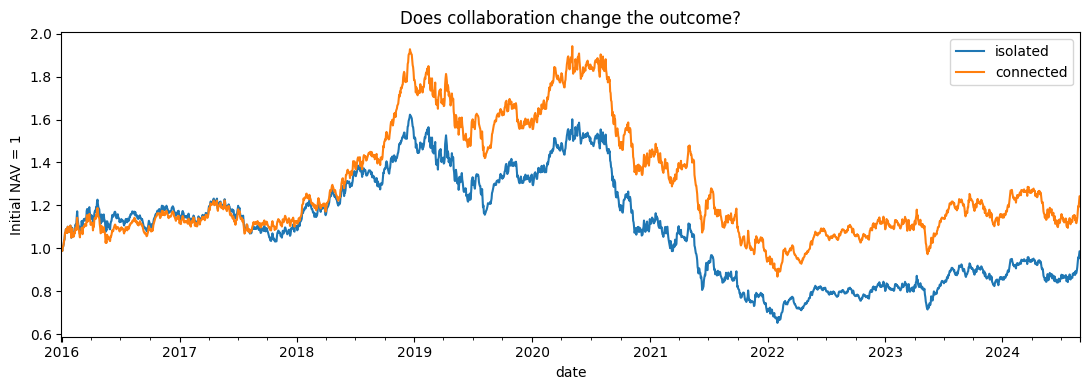

,total_return,annualized_return,annualized_volatility,max_drawdown,observations,total_cost,traded_notional_turnover
isolated,-0.0137,-0.0015,0.1956,-0.5976,2259.0,12186.0103,110.6987
connected,0.2426,0.0245,0.1907,-0.5527,2259.0,12608.1555,98.8915


In [ ]:
def ecosystem_policy(view,ecosystem):
    def policy(asof,context):
        return ecosystem.coordinate(view,asof,required_capabilities(view.environment(asof)))
    return policy
isolated=Ecosystem(collaborate=False)
connected=Ecosystem(collaborate=True)
base=run_book(view,ecosystem_policy(view,isolated),'isolated_ecosystem',dates=schedule)
federated=run_book(view,ecosystem_policy(view,connected),'connected_ecosystem',dates=schedule)
save_book(base,RESULTS_DIR);save_book(federated,RESULTS_DIR)
plot_books({'isolated':base,'connected':federated},'Does collaboration change the outcome?')
display(compare_books({'isolated':base,'connected':federated}).round(4))

#### Understanding the `ecosystem_policy` Function

Code Unit 7 introduces the `ecosystem_policy` function, which acts as a crucial interface between the `run_book` simulation engine and our `Ecosystem` objects. Its primary purpose is to define *how* an ecosystem makes investment decisions at each step of a simulation.

Let's dissect its structure and purpose:

```python
def ecosystem_policy(view,ecosystem):
    def policy(asof,context):
        return ecosystem.coordinate(view,asof,required_capabilities(view.environment(asof)))
    return policy
```

1.  **`def ecosystem_policy(view,ecosystem):`**
    *   This is the outer function. It takes two main arguments:
        *   `view`: This object represents the **market view** or the available information about the investment environment (e.g., asset prices, economic conditions). It allows the policy to access current market data.
        *   `ecosystem`: This is an instance of our `Ecosystem` class (either `isolated` or `connected`). It's the central agent that orchestrates the `Constellation` teams and their interactions.
    *   The `ecosystem_policy` function doesn't directly return a decision; instead, it returns *another function* called `policy`. This is a powerful Python concept called a **closure**, where the inner `policy` function 'remembers' the `view` and `ecosystem` objects from its outer scope, even after `ecosystem_policy` has finished executing.

2.  **`def policy(asof,context):`**
    *   This is the inner function that `ecosystem_policy` returns. This `policy` function is designed to be passed to the `run_book` simulation engine. `run_book` will call this `policy` function repeatedly at each simulation step (i.e., each `asof` date).
    *   It takes two arguments:
        *   `asof`: Represents the **current date** in the simulation. Decisions are made 'as of' this date.
        *   `context`: Provides additional simulation-specific information (though it's not directly used in this particular `policy`'s logic here).

3.  **`return ecosystem.coordinate(view,asof,required_capabilities(view.environment(asof)))`**
    *   This is the core of the decision-making logic within our `policy` function.
    *   **`view.environment(asof)`**: At the current simulation date (`asof`), this gets the relevant environmental information from the `view` object.
    *   **`required_capabilities(view.environment(asof))`**: Based on the current environment, this function determines what capabilities are *needed* by the `Constellation` teams. For example, if the environment indicates high market volatility, it might require 'low_volatility' capabilities.
    *   **`ecosystem.coordinate(...)`**: This is where the magic happens! The `ecosystem` object (which was captured from the outer `ecosystem_policy` function) is instructed to `coordinate` its `Constellation` teams. It receives the `view` (market data), the `asof` date, and the `required_capabilities` for this period. The `coordinate` method then orchestrates communication, negotiation, and decision-making among its teams, ultimately returning the overall portfolio `decision` for that `asof` date.

#### Why this structure?

This nested function structure (`ecosystem_policy` returning `policy`) allows us to:
*   **Configure a policy**: We can create specific `policy` functions tailored to different `Ecosystem` instances (e.g., one for `isolated` and one for `connected`) without rewriting the core `coordinate` logic.
*   **Integrate with `run_book`**: The `run_book` function expects a policy function that takes `asof` and `context` as arguments. Our `policy` function perfectly matches this signature.

In essence, `ecosystem_policy` is a factory for creating specific `policy` functions that tell the `run_book` how each `Ecosystem` (isolated or connected) should generate its investment decisions at every step of the simulation. This allows for a clean comparison of how the 'collaboration' mechanism (enabled in `connected` but not in `isolated`) impacts the final portfolio decisions and overall performance.

### Code Unit 8 of 10 — Visualize sector allocation and interaction activity

The area chart aggregates the final five-stock holdings into sectors at each rebalance. Because every position has twenty-percent target weight, sector allocations move in corresponding increments. The message counts summarize how frequently the ecosystem requested, negotiated, delivered, and dissolved services. Read the two outputs together with the detailed logs. A high message count alone could indicate wasteful coordination, while a large allocation change without an explanatory contract could reveal a missing causal link in the implementation.

**Expected observation.** The allocation chart should sum to one at each rebalance. The message counts should include more than formation alone. Requests that fail and relationships that expire are part of the ecosystem’s behavior and should remain visible.

After execution, compare the output with the stated contract and trace at least one value back to its input. If a check fails, resolve the cause before continuing, because later units rely on this result.

**Reflect:** Why is the number of messages not a measure of intelligence?

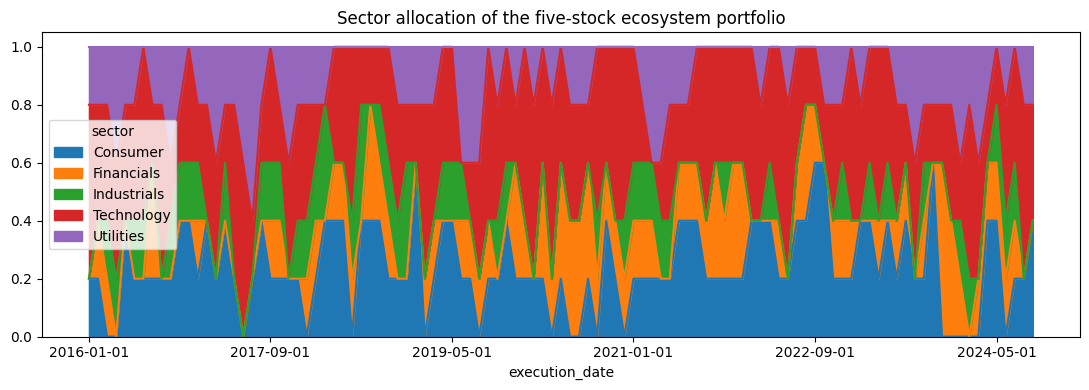

,messages
kind,
accept,184
counteroffer,209
deliver,184
dissolve,182
form,184
offer,209
reject,105
request,235


In [ ]:
def sector_weights(positions):
    return positions.pivot_table(index='execution_date',columns='sector',values='target_weight',aggfunc='sum',fill_value=0)
sector_weights(federated['positions']).plot.area(figsize=(11,4),title='Sector allocation of the five-stock ecosystem portfolio')
plt.tight_layout();plt.show()
display(pd.DataFrame(connected.messages).groupby('kind').size().rename('messages'))

### Code Unit 9 of 10 — Evaluate completed outcomes against hidden regimes

Only after the investment experiments are complete do we load the teacher regime file. It is joined to realized daily returns for descriptive evaluation. The resulting table compares styles and organizations across the environments used by the generator. It does not simulate an investor who knew those labels beforehand. The final-window comparison uses the same cutoff across every book. Remember that compounding selected regime days is a descriptive aggregate over potentially disconnected dates, not an implementable regime-timing strategy.

**Expected observation.** The regime report should contain descriptive results for completed returns only. These labels were excluded from the agent-facing view. Their appearance here must not be confused with a live signal that the investor could have used prospectively.

After execution, compare the output with the stated contract and trace at least one value back to its input. If a check fails, resolve the cause before continuing, because later units rely on this result.

**Reflect:** Why are regime labels introduced after decisions rather than before them?

In [ ]:
def regime_evaluation(equities,teacher):
    labels=teacher.set_index('date').regime
    rows=[]
    for name,e in equities.items():
        joined=e.pct_change().rename('return').to_frame().join(labels).dropna()
        for regime,g in joined.groupby('regime'):
            rows.append({'book':name,'regime':regime,'days':len(g),'mean_daily_return':g['return'].mean(),
                'daily_volatility':g['return'].std(),'compounded_selected_days':(1+g['return']).prod()-1})
    return pd.DataFrame(rows)
# Evaluation only: teacher labels enter here after every portfolio decision is complete.
teacher=pd.read_csv(DATASET_DIR/'teacher_regimes.csv',parse_dates=['date'])
equities={s:pd.read_csv(RESULTS_DIR/f'{s}_equity.csv',index_col='date',parse_dates=True).nav for s in STYLES+['fixed','feedback','adaptive']}
equities.update({'isolated':base['equity'],'connected':federated['equity']})
by_regime=regime_evaluation(equities,teacher)
display(by_regime.round(5))
by_regime.to_csv(RESULTS_DIR/'NB05_regime_evaluation.csv',index=False)
all_holdout=pd.DataFrame({k:performance(v.loc[view.dates[1764]:]) for k,v in equities.items()}).T
display(all_holdout.round(4));all_holdout.to_csv(RESULTS_DIR/'NB05_all_holdout.csv')

,book,regime,days,mean_daily_return,daily_volatility,compounded_selected_days
0,momentum,expansion,303,0.00098,0.00974,0.32474
1,momentum,recession,836,-0.00104,0.02251,-0.66119
2,momentum,recovery,633,0.00093,0.01339,0.70305
3,momentum,slowdown,487,0.00122,0.01380,0.73022
4,value,expansion,303,0.00075,0.00938,0.23984
5,value,recession,836,-0.00131,0.02560,-0.74703
6,value,recovery,633,0.00077,0.01210,0.55447
7,value,slowdown,487,0.00081,0.01379,0.41362
8,quality,expansion,303,0.00077,0.00868,0.24850
9,quality,recession,836,-0.00118,0.02344,-0.70499


,total_return,annualized_return,annualized_volatility,max_drawdown,observations
momentum,0.2861,0.0876,0.2449,-0.2756,755.0
value,0.2395,0.0743,0.2708,-0.2594,755.0
quality,0.1787,0.0564,0.2556,-0.2692,755.0
defensive,0.0991,0.0320,0.1616,-0.1821,755.0
reversion,-0.1181,-0.0411,0.2590,-0.3093,755.0
fixed,0.3012,0.0919,0.1969,-0.2242,755.0
feedback,0.2972,0.0907,0.1971,-0.1967,755.0
adaptive,0.1142,0.0367,0.1830,-0.1828,755.0
isolated,0.2479,0.0767,0.1825,-0.1878,755.0
connected,0.1819,0.0574,0.1813,-0.1974,755.0


### Code Unit 10 of 10 — Verify the complete ecosystem and save its evidence

The final assertions require actual contracts, deliveries, rejections, dissolutions, and five-stock allocations. They also require at least one difference between connected and isolated portfolio selections. This proves that interaction has an operational consequence, while leaving its economic value to the performance analysis. Contracts and messages are saved for review. The completed course now contains a continuous construction from data to individual action, organized collaboration, feedback, team reconfiguration, and temporary coordination among independently identified constellations.

**Expected observation.** The pass message should confirm changed selections as well as actual protocol events. This establishes an implemented ecosystem rather than a diagram-only concept. The saved evidence supports tracing both successful alliances and unsuccessful coordination attempts.

After execution, compare the output with the stated contract and trace at least one value back to its input. If a check fails, resolve the cause before continuing, because later units rely on this result.

**Reflect:** Which saved records demonstrate that the ecosystem was dynamic?

In [ ]:
assert connected.contracts and any(m['kind']=='deliver' for m in connected.messages)
assert any(m['kind']=='dissolve' for m in connected.messages)
assert any(m['kind']=='reject' for m in connected.messages)
assert (federated['positions'].groupby('asof').ticker.nunique()==5).all()
assert np.allclose(federated['positions'].target_weight,.2)
changed=(base['positions'].groupby('asof').ticker.apply(tuple)!=federated['positions'].groupby('asof').ticker.apply(tuple)).sum()
assert changed>0
(RESULTS_DIR/'NB05_contracts.json').write_text(json.dumps(connected.contracts,indent=2))
(RESULTS_DIR/'NB05_messages.json').write_text(json.dumps(connected.messages,indent=2,default=str))
print('PASS: discovery, negotiation, knowledge delivery, alliances, dissolution, and changed selections.')
print('Months with different portfolios:',changed)
print('Journey complete: primitives → constellations → loops → reconfiguration → ecosystems.')

PASS: discovery, negotiation, knowledge delivery, alliances, dissolution, and changed selections.
Months with different portfolios: 81
Journey complete: primitives → constellations → loops → reconfiguration → ecosystems.


###The Narrative

Imagine an algorithmic-trading platform built not as one giant model, but as a small organization of specialized strategy teams. Each team knows how to interpret the market in a different way, and each one can contribute a distinct kind of signal. The logic of Notebook 05 is to make those teams behave less like isolated algorithms and more like departments inside an investment firm that can discover one another, exchange information, collaborate temporarily, and then separate again when the need has passed.

The system begins with three trading constellations. Growth contains momentum and quality strategies. Recovery contains value and mean-reversion strategies. Preservation contains a defensive strategy. Each constellation therefore starts with its own native trading logic. Growth looks for persistent trends and strong fundamentals. Recovery looks for valuation opportunities and reversals. Preservation emphasizes resilience and low volatility.

At each rebalance date, the system first observes the market environment. From that observation it infers which capabilities appear important at that moment. During a stress episode, for example, the required capabilities may be resilience and low volatility. Each constellation then compares those requirements with the capabilities already provided by its own strategies.

If a constellation already possesses what it needs, it can proceed independently. If something is missing, it can ask another constellation for assistance. This is the first important transformation from a conventional ensemble. The system does not automatically combine every strategy all the time. Collaboration occurs only when a capability gap exists.

Suppose Growth has resilience through its quality strategy but lacks low-volatility expertise. Growth sends a request for that missing capability. Preservation can provide it through the defensive strategy. Preservation responds with an offer. Growth has a limited collaboration budget, so it may counteroffer. If an agreement is reached, the system creates a temporary alliance.

In trading terms, that alliance gives Growth temporary access to Preservation’s stock-ranking signal. Growth does not replace its momentum and quality strategies. Instead, it supplements their rankings with the ranking supplied by Preservation. The Growth portfolio decision is therefore produced from a temporary combination of native and borrowed signals.

The same process can happen elsewhere in the ecosystem. Recovery may need resilience. It can seek help from Growth or Preservation depending on which provider has the required capability and still has available capacity. Because each provider can serve only a limited number of external requests in a cycle, not every request is guaranteed to succeed. A relevant provider may reject a request simply because its capacity has already been consumed.

This scarcity is deliberate. Without it, every constellation could simply import every useful signal, and the ecosystem would collapse into one permanent universal ensemble. The notebook instead creates a resource-constrained network in which the pattern of collaboration depends on current market needs, available strategies, budgets, capacity, and request order.

After collaboration has been resolved, each constellation produces its own portfolio ranking. For Growth, that ranking may combine momentum, quality, and a temporarily borrowed defensive signal. Recovery may combine value, mean reversion, and a borrowed quality signal. Preservation may operate only with its native defensive ranking if it already has everything required.

The ecosystem then performs a second level of aggregation. The three constellation-level decisions are passed to an ecosystem coordinator. The coordinator combines them and constructs the final portfolio. The portfolio mandate remains fixed: exactly five stocks, each with a target weight of twenty percent.

This is important because collaboration changes the information entering the decision process, but it does not change the governance rules. The final portfolio must still satisfy the same position count, equal-weight rule, liquidity constraints, sector limits, review process, and execution discipline used elsewhere in the tutorial.

The alliances are also temporary. Each contract expires after twenty-five days. When its expiration date is reached, the alliance is removed from the active network, the contract remains in the historical record as expired, and a dissolution message is written to the message log. The system therefore does not permanently accumulate every collaboration it has ever created. Its organizational topology can expand, contract, and reorganize over time.

The notebook then runs the critical experiment. Two algorithmic-trading systems face exactly the same market and rebalance schedule. In the isolated system, Growth, Recovery, and Preservation can use only their native strategies. In the connected system, they can request capabilities, negotiate access, receive rankings, and form temporary alliances.

Everything else is kept constant. The market data are the same. The portfolio rules are the same. The transaction costs are the same. The review and execution mechanisms are the same. The experimental variable is collaboration itself.

This allows a clean question to be asked: does allowing strategy organizations to exchange capabilities actually change the investment outcome?

The notebook examines this question in several ways. It compares the equity curves of the isolated and connected systems. It studies how sector allocations change through time. It counts the messages generated by requests, offers, counteroffers, acceptances, deliveries, rejections, formations, and dissolutions. These messages provide an audit trail of how the ecosystem reorganized itself.

After all trading decisions have been completed, the notebook introduces the hidden teacher regime labels only for evaluation. These labels were never available to the trading strategies when they made decisions. They are used retrospectively to examine how the different strategies and architectures behaved during expansion, slowdown, recession, and recovery periods.

The final validation asks whether the ecosystem was truly operational. Contracts must have been created. Ranking signals must have been delivered. Some requests must have been rejected. Temporary alliances must have dissolved. Every portfolio must still contain exactly five stocks at twenty percent each. Finally, the connected and isolated systems must select different portfolios on at least some dates.

That final condition is especially important. If collaboration produces exactly the same portfolio every time, the ecosystem may be organizationally interesting but economically irrelevant. If signal exchange changes which stocks are selected, then the collaboration mechanism has become part of the actual trading process.

The algorithmic-trading lesson is therefore deeper than simply adding more models. Momentum, value, quality, defensive, and mean-reversion strategies remain specialized modules. What becomes dynamic is the network connecting them. Market conditions determine what capabilities are needed. Capability gaps trigger requests. Requests create temporary access to other strategies. Shared rankings modify local portfolio decisions. Local decisions are aggregated into an ecosystem portfolio. Alliances later disappear, and the process begins again.

The result is not one enormous trading algorithm. It is a changing ecosystem of specialized trading systems that can temporarily reorganize themselves around the market problem they face at each point in time.

###Conclusions

Notebook 05 completes the five-step progression by making inter-constellation relationships operational. Growth, Recovery, and Preservation teams can discover missing capabilities, request services, negotiate within constraints, exchange evidence, and create temporary alliances. Those alliances can expire and dissolve. The architecture therefore changes at the level of relationships between organizations, extending the internal reconfiguration introduced in Notebook 04.

The message log is central evidence. Requests, offers, counteroffers, acceptances, rejections, deliveries, formations, and dissolutions are recorded as separate events. A learner can trace one capability gap through the complete protocol and identify where an agreement failed or succeeded. This is more informative than a diagram claiming that agents collaborate without an executable exchange behind the arrows.

Collaboration also has a measurable consequence. A delivered capability contributes to the requester's decision, and that decision contributes to the final five-stock portfolio. The isolated comparison uses the same base teams but disables external collaboration. Differences in selected stocks therefore show that the interaction mechanism is operational. Differences in returns, costs, or drawdowns show its consequences in this particular synthetic experiment; they do not establish a general superiority of connected systems.

Scarcity creates important behavior. A provider can serve only one external requester during a cycle, and a requester has a limited access budget. Requests that arrive later may fail even when a relevant capability exists. The protocol therefore exposes questions about fairness, ordering, and alternative allocation mechanisms. Credits here are access quotas, not a conserved economic currency. A richer market design would need explicit accounting and a separate analysis of incentives.

The retrospective regime report closes the information boundary correctly. Teacher labels are joined to completed return histories only after the decisions have been made. This lets us describe how styles and organizations behaved across the generator's regimes without granting that knowledge to the agents in advance. Compounded returns over selected regime days are descriptive aggregates, not the returns of a strategy that could foresee and trade only those days.

Looking across the sequence, the same simple portfolio mandate supported several distinct engineering achievements. We built an environment, gave an individual agent tools and skills, coordinated specialists, introduced feedback, reconfigured a team, and then connected teams through a changing network of services. The reusable lesson is how increasingly sophisticated agency can be constructed from explicit components whose decisions and interactions remain observable.

For an independent exercise, select one accepted contract and reconstruct the complete message sequence from request through dissolution. Identify the capability gap, offered provider, negotiated quota, delivered ranking, resulting alliance, and expiry. Then locate a rejected request and explain which resource constraint prevented agreement. These two paths together reveal more about the ecosystem than a final equity curve alone.

You should now be able to describe the entire ladder using concrete objects in the bundle. The action packet represents a primitive agent, the collaboration packet represents a constellation, the event history represents feedback, the plan represents internal reconfiguration, and the contract log represents coordination across constellations. Each new level preserves the earlier mechanisms while adding a distinct organizational capability.

Before continuing, review the saved artifacts and explain one complete example in your own words. Treat a failed assertion as useful evidence about a broken assumption. Correct that assumption before comparing results. The purpose of this cumulative journey is to understand the mechanism well enough to modify it deliberately, rather than simply collect successful execution messages.

**Continue the journey:** Use the saved comparison tables, plans, and contract logs to design your next controlled experiment.

**Implementation references:** [OpenAI function calling](https://developers.openai.com/api/docs/guides/function-calling) · [GPT-5 nano model](https://developers.openai.com/api/docs/models/gpt-5-nano). The introduction and conceptual lesson explain this notebook’s match with the investment banking sequence.

###Appendix. LLM Implementation

In [ ]:
from google.colab import userdata

try:
    key = userdata.get("OPENAI_API_KEY")

    print("Secret found:", bool(key))

    if key:
        print("✓ OPENAI_API_KEY is accessible to this notebook")
        print("Key length:", len(key))
    else:
        print("Secret exists but Colab returned an empty value")

except Exception as e:
    print("Colab error type:", type(e).__name__)
    print("Colab error:", e)

Secret found: True
✓ OPENAI_API_KEY is accessible to this notebook
Key length: 164


In [ ]:
!pip install -q OpenAI

In [ ]:
import openai


✓ Normal NB05 objects are available
✓ OPENAI_API_KEY available
✓ LLM model: gpt-5-nano
✓ Cache: /content/drive/MyDrive/Colab Notebooks/TOPIC_767 ALGORITHMIC_TRADING_AGENTIC_SYSTEMS/RESULTS/API_CACHE_NB05_LLM
✓ Self-contained LLM selector installed
✓ LLM ecosystem backtest completed

LLM PROVIDER-SELECTION AUDIT


,candidate_providers,choice,mode,explanation
0,[Preservation],Preservation,single_feasible_provider,Only one feasible provider existed; no LLM cal...
1,[Growth],Growth,single_feasible_provider,Only one feasible provider existed; no LLM cal...
2,[Preservation],Preservation,single_feasible_provider,Only one feasible provider existed; no LLM cal...
3,[Growth],Growth,single_feasible_provider,Only one feasible provider existed; no LLM cal...
4,[Preservation],Preservation,single_feasible_provider,Only one feasible provider existed; no LLM cal...
...,...,...,...,...
179,[Growth],Growth,single_feasible_provider,Only one feasible provider existed; no LLM cal...
180,[Preservation],Preservation,single_feasible_provider,Only one feasible provider existed; no LLM cal...
181,[Growth],Growth,single_feasible_provider,Only one feasible provider existed; no LLM cal...
182,[Preservation],Preservation,single_feasible_provider,Only one feasible provider existed; no LLM cal...


,decisions
mode,
live_llm,25
single_feasible_provider,159


Fresh OpenAI API calls: 25


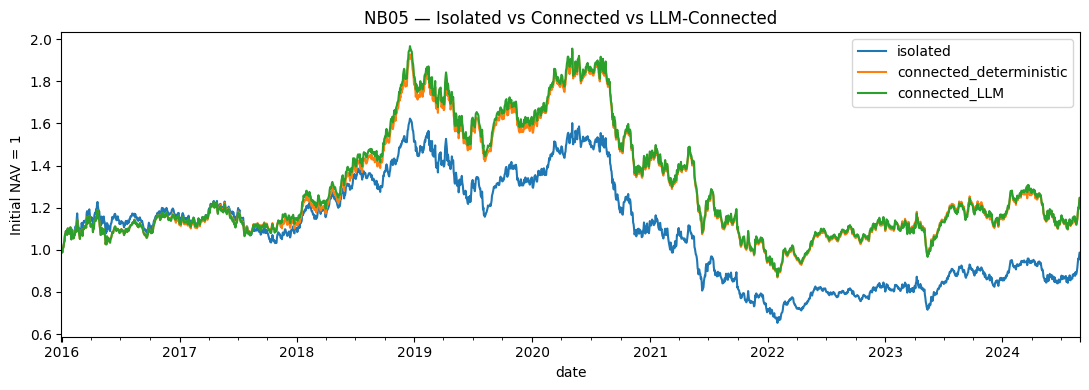

,total_return,annualized_return,annualized_volatility,max_drawdown,observations,total_cost,traded_notional_turnover
isolated,-0.0137,-0.0015,0.1956,-0.5976,2259.0,12186.0103,110.6987
connected_deterministic,0.2426,0.0245,0.1907,-0.5527,2259.0,12608.1555,98.8915
connected_LLM,0.2469,0.0249,0.1896,-0.5553,2259.0,13190.6509,102.8089



Months where deterministic-connected and LLM-connected portfolios differ: 13

NB05 OPTIONAL LIVE-LLM EXPERIMENT COMPLETE
✓ No lab package required
✓ No OpenAI SDK required
✓ Deterministic classroom experiment unchanged
✓ Same market
✓ Same strategies
✓ Same capability catalog
✓ Same negotiation rules
✓ Same budgets
✓ Same provider capacity constraints
✓ Same alliance lifecycle
✓ Same five-stock portfolio
✓ Same 20% target weights
✓ Same review and execution architecture

LLM role only:
capability gap → multiple feasible providers → LLM chooses provider → temporary alliance → ranking delivered → portfolio may change

Saved experiment: connected_ecosystem_llm


In [ ]:
# ================================================================
# NB05 — OPTIONAL LIVE-LLM ECOSYSTEM EXPERIMENT
# SELF-CONTAINED VERSION
#
# Paste AFTER the conclusions.
#
# NO lab import.
# NO OpenAI Python SDK.
#
# Assumes the normal NB05 has already run, so these objects exist:
#   Ecosystem, view, schedule, required_capabilities,
#   run_book, save_book, plot_books, compare_books,
#   base, federated, RESULTS_DIR
#
# The deterministic/classroom experiment remains untouched.
# ================================================================

import os
import json
import hashlib
import urllib.request
import urllib.error
from pathlib import Path

import numpy as np
import pandas as pd


# ================================================================
# 1. CHECK THAT THE NORMAL NB05 HAS ALREADY RUN
# ================================================================

required_objects = [
    "Ecosystem",
    "view",
    "schedule",
    "required_capabilities",
    "run_book",
    "save_book",
    "plot_books",
    "compare_books",
    "base",
    "federated",
    "RESULTS_DIR"
]

missing = [x for x in required_objects if x not in globals()]

if missing:
    raise RuntimeError(
        "Run the normal NB05 first. Missing objects: "
        + ", ".join(missing)
    )

print("✓ Normal NB05 objects are available")


# ================================================================
# 2. GET OPENAI_API_KEY DIRECTLY FROM COLAB SECRETS
# ================================================================

def get_openai_key():

    key = os.environ.get("OPENAI_API_KEY")

    if not key:
        try:
            from google.colab import userdata
            key = userdata.get("OPENAI_API_KEY")
        except Exception:
            key = None

    if not key:
        raise RuntimeError(
            "OPENAI_API_KEY was not found. "
            "Add it to Colab Secrets with notebook access enabled."
        )

    return key


OPENAI_API_KEY = get_openai_key()

print("✓ OPENAI_API_KEY available")


# ================================================================
# 3. CONFIGURATION
# ================================================================

LLM_MODEL = "gpt-5-nano"

LLM_CACHE = Path(RESULTS_DIR) / "API_CACHE_NB05_LLM"
LLM_CACHE.mkdir(parents=True, exist_ok=True)

LLM_DECISION_LOG = []

LLM_API_CALLS = 0

print("✓ LLM model:", LLM_MODEL)
print("✓ Cache:", LLM_CACHE)


# ================================================================
# 4. EXTRACT TEXT FROM A RESPONSES API PAYLOAD
# ================================================================

def extract_response_text(payload):

    # Some responses expose output_text directly.
    direct = payload.get("output_text")

    if isinstance(direct, str) and direct.strip():
        return direct.strip()

    # Otherwise inspect assistant message items.
    for item in payload.get("output", []):

        if not isinstance(item, dict):
            continue

        if item.get("type") != "message":
            continue

        for content in item.get("content", []):

            if not isinstance(content, dict):
                continue

            if content.get("type") == "output_text":

                text = content.get("text")

                if isinstance(text, str) and text.strip():
                    return text.strip()

    return ""


# ================================================================
# 5. CALL THE LLM TO CHOOSE AMONG FEASIBLE PROVIDERS
#
# IMPORTANT:
#
# The model CANNOT invent another provider.
#
# The JSON schema restricts "choice" to the provider names
# already identified as feasible by the deterministic ecosystem.
# ================================================================

def llm_choose_provider(prompt, options):

    global LLM_API_CALLS

    options = list(options)

    if len(options) < 2:
        raise ValueError(
            "LLM provider selection requires at least two options."
        )

    # ------------------------------------------------------------
    # CACHE
    # ------------------------------------------------------------

    cache_key = hashlib.sha256(
        json.dumps(
            {
                "model": LLM_MODEL,
                "prompt": prompt,
                "options": options
            },
            sort_keys=True
        ).encode()
    ).hexdigest()

    cache_file = LLM_CACHE / f"{cache_key}.json"

    if cache_file.exists():

        cached = json.loads(cache_file.read_text())

        return {
            "choice": cached["choice"],
            "explanation": cached["explanation"],
            "mode": "cached_llm"
        }


    # ------------------------------------------------------------
    # STRUCTURED OUTPUT SCHEMA
    # ------------------------------------------------------------

    schema = {
        "type": "object",
        "properties": {
            "choice": {
                "type": "string",
                "enum": options
            },
            "explanation": {
                "type": "string"
            }
        },
        "required": [
            "choice",
            "explanation"
        ],
        "additionalProperties": False
    }


    system_instruction = """
You are the bounded peer-selection planner inside a pedagogical
algorithmic-trading ecosystem.

The deterministic trading system has already identified the peer
providers that are feasible.

Your ONLY task is to select one provider from the authorized list.

Use the supplied:
- requesting constellation
- missing capabilities
- provider capabilities
- observed market environment

Do not invent another provider.
Do not invent prices.
Do not modify strategies.
Do not change portfolio rules.
Do not execute trades.

Return the structured answer required by the supplied JSON schema.
""".strip()


    body = {
        "model": LLM_MODEL,

        "reasoning": {
            "effort": "minimal"
        },

        "input": [
            {
                "role": "system",
                "content": system_instruction
            },
            {
                "role": "user",
                "content": prompt
            }
        ],

        "text": {
            "format": {
                "type": "json_schema",
                "name": "nb05_provider_selection",
                "strict": True,
                "schema": schema
            }
        },

        "max_output_tokens": 2000
    }


    request = urllib.request.Request(
        "https://api.openai.com/v1/responses",

        data=json.dumps(body).encode("utf-8"),

        headers={
            "Authorization": f"Bearer {OPENAI_API_KEY}",
            "Content-Type": "application/json"
        },

        method="POST"
    )


    # ------------------------------------------------------------
    # API CALL
    # ------------------------------------------------------------

    try:

        with urllib.request.urlopen(
            request,
            timeout=120
        ) as response:

            payload = json.loads(
                response.read().decode("utf-8")
            )

    except urllib.error.HTTPError as exc:

        detail = exc.read().decode(
            "utf-8",
            errors="replace"
        )

        raise RuntimeError(
            f"OpenAI API HTTP {exc.code}: "
            f"{detail[:1500]}"
        ) from exc

    except urllib.error.URLError as exc:

        raise RuntimeError(
            f"Could not reach OpenAI API: {exc}"
        ) from exc


    LLM_API_CALLS += 1


    # ------------------------------------------------------------
    # VERIFY RESPONSE
    # ------------------------------------------------------------

    response_text = extract_response_text(payload)

    if not response_text:

        raise RuntimeError(
            "OpenAI returned no final provider selection. "
            f"status={payload.get('status')}; "
            f"incomplete_details={payload.get('incomplete_details')}; "
            f"response_id={payload.get('id')}"
        )


    result = json.loads(response_text)

    choice = result["choice"]
    explanation = result["explanation"]


    if choice not in options:

        raise RuntimeError(
            f"Unauthorized provider returned by LLM: {choice}"
        )


    # ------------------------------------------------------------
    # SAVE CACHE
    # ------------------------------------------------------------

    cache_file.write_text(
        json.dumps(
            {
                "choice": choice,
                "explanation": explanation,
                "response_id": payload.get("id"),
                "model": payload.get("model", LLM_MODEL)
            },
            indent=2
        )
    )


    return {
        "choice": choice,
        "explanation": explanation,
        "mode": "live_llm"
    }


# ================================================================
# 6. DEFINE THE FUNCTION THAT Ecosystem.coordinate() EXPECTS
#
# This deliberately has the same signature as the notebook's
# original choose_with_model().
#
# Ecosystem.coordinate() already calls:
#
#     choose_with_model(...)[ "choice" ]
#
# when peer offers exist.
#
# We replace that selector ONLY for this optional experiment.
# ================================================================

def nb05_choose_with_model(
    prompt,
    options,
    execute,
    cache_dir,
    live=False,
    fallback=None,
    *args,
    **kwargs
):

    options = list(options)

    if not options:
        raise ValueError("No feasible providers.")


    # ------------------------------------------------------------
    # NORMAL DETERMINISTIC PATH
    # ------------------------------------------------------------

    if not live:

        choice = (
            fallback
            if fallback in options
            else options[0]
        )

        return {
            "choice": choice,
            "result": execute(choice),
            "mode": "deterministic_policy",
            "explanation": "LLM disabled."
        }


    # ------------------------------------------------------------
    # ONLY ONE FEASIBLE PROVIDER
    #
    # There is no decision for an LLM to make.
    # ------------------------------------------------------------

    if len(options) == 1:

        choice = options[0]

        packet = {
            "choice": choice,
            "result": execute(choice),
            "mode": "single_feasible_provider",
            "explanation": (
                "Only one feasible provider existed; "
                "no LLM call was necessary."
            )
        }

        LLM_DECISION_LOG.append({
            "candidate_providers": options,
            "choice": choice,
            "mode": packet["mode"],
            "explanation": packet["explanation"]
        })

        return packet


    # ------------------------------------------------------------
    # GENUINE CHOICE:
    # TWO OR MORE FEASIBLE PROVIDERS
    # ------------------------------------------------------------

    answer = llm_choose_provider(
        prompt,
        options
    )

    choice = answer["choice"]


    packet = {
        "choice": choice,
        "result": execute(choice),
        "mode": answer["mode"],
        "explanation": answer["explanation"]
    }


    LLM_DECISION_LOG.append({
        "candidate_providers": options,
        "choice": choice,
        "mode": answer["mode"],
        "explanation": answer["explanation"]
    })


    return packet


# ================================================================
# 7. TEMPORARILY REPLACE choose_with_model
#
# Unit 3's Ecosystem class looks up this global name when
# coordinate() runs.
# ================================================================

_original_choose_with_model = globals().get(
    "choose_with_model",
    None
)

choose_with_model = nb05_choose_with_model

print("✓ Self-contained LLM selector installed")


# ================================================================
# 8. DEFINE A LIVE-LLM ECOSYSTEM POLICY
# ================================================================

def ecosystem_policy_llm(view, ecosystem):

    def policy(asof, context):

        environment = view.environment(asof)

        required = required_capabilities(
            environment
        )

        return ecosystem.coordinate(
            view,
            asof,
            required,
            live=True,
            cache_dir=LLM_CACHE
        )

    return policy


# ================================================================
# 9. CREATE A FRESH ECOSYSTEM
#
# Do not contaminate the deterministic `connected` ecosystem.
# ================================================================

connected_llm = Ecosystem(
    collaborate=True
)


# ================================================================
# 10. RUN THE COMPLETE BACKTEST WITH THE LLM ON
# ================================================================

try:

    federated_llm = run_book(
        view,
        ecosystem_policy_llm(
            view,
            connected_llm
        ),
        "connected_ecosystem_llm",
        dates=schedule
    )

finally:

    # Restore the original notebook selector afterward.
    if _original_choose_with_model is not None:
        choose_with_model = _original_choose_with_model


print("✓ LLM ecosystem backtest completed")


# ================================================================
# 11. SAVE RESULTS
# ================================================================

save_book(
    federated_llm,
    RESULTS_DIR
)


(RESULTS_DIR / "NB05_LLM_contracts.json").write_text(
    json.dumps(
        connected_llm.contracts,
        indent=2,
        default=str
    )
)


(RESULTS_DIR / "NB05_LLM_messages.json").write_text(
    json.dumps(
        connected_llm.messages,
        indent=2,
        default=str
    )
)


llm_decisions = pd.DataFrame(
    LLM_DECISION_LOG
)


llm_decisions.to_csv(
    RESULTS_DIR / "NB05_LLM_provider_decisions.csv",
    index=False
)


# ================================================================
# 12. SHOW EXACTLY WHERE THE LLM WAS USED
# ================================================================

print()
print("=" * 72)
print("LLM PROVIDER-SELECTION AUDIT")
print("=" * 72)


if len(llm_decisions):

    display(llm_decisions)

    print()

    display(
        llm_decisions
        .groupby("mode")
        .size()
        .rename("decisions")
        .to_frame()
    )

else:

    print(
        "No provider-selection decisions were required."
    )


print("Fresh OpenAI API calls:", LLM_API_CALLS)


# ================================================================
# 13. COMPARE THE THREE SYSTEMS
# ================================================================

comparison_books = {

    "isolated":
        base,

    "connected_deterministic":
        federated,

    "connected_LLM":
        federated_llm
}


plot_books(
    comparison_books,
    "NB05 — Isolated vs Connected vs LLM-Connected"
)


display(
    compare_books(
        comparison_books
    ).round(4)
)


# ================================================================
# 14. DID LLM COLLABORATION CHANGE STOCK SELECTION?
# ================================================================

deterministic_portfolios = (
    federated["positions"]
    .groupby("asof")
    .ticker
    .apply(tuple)
)


llm_portfolios = (
    federated_llm["positions"]
    .groupby("asof")
    .ticker
    .apply(tuple)
)


common_dates = (
    deterministic_portfolios.index
    .intersection(
        llm_portfolios.index
    )
)


llm_changed = int(
    (
        deterministic_portfolios.loc[common_dates]
        !=
        llm_portfolios.loc[common_dates]
    ).sum()
)


print()
print(
    "Months where deterministic-connected and "
    "LLM-connected portfolios differ:",
    llm_changed
)


# ================================================================
# 15. VERIFY THAT ALL ORIGINAL GOVERNANCE RULES STILL HOLD
# ================================================================

assert connected_llm.contracts

assert any(
    m["kind"] == "deliver"
    for m in connected_llm.messages
)

assert any(
    m["kind"] == "dissolve"
    for m in connected_llm.messages
)

assert any(
    m["kind"] == "reject"
    for m in connected_llm.messages
)

assert (
    federated_llm["positions"]
    .groupby("asof")
    .ticker
    .nunique()
    == 5
).all()

assert np.allclose(
    federated_llm["positions"]
    .target_weight,
    0.20
)


# ================================================================
# 16. FINAL INTERPRETATION
# ================================================================

print()
print("=" * 72)
print("NB05 OPTIONAL LIVE-LLM EXPERIMENT COMPLETE")
print("=" * 72)

print("✓ No lab package required")
print("✓ No OpenAI SDK required")
print("✓ Deterministic classroom experiment unchanged")
print("✓ Same market")
print("✓ Same strategies")
print("✓ Same capability catalog")
print("✓ Same negotiation rules")
print("✓ Same budgets")
print("✓ Same provider capacity constraints")
print("✓ Same alliance lifecycle")
print("✓ Same five-stock portfolio")
print("✓ Same 20% target weights")
print("✓ Same review and execution architecture")

print()
print("LLM role only:")
print(
    "capability gap"
    " → multiple feasible providers"
    " → LLM chooses provider"
    " → temporary alliance"
    " → ranking delivered"
    " → portfolio may change"
)

print()
print(
    "Saved experiment: connected_ecosystem_llm"
)

End of the Notebook